# Austria’s Baby Deficit: How Housing Costs and Economic Pressure Are Keeping Birth Rates Low 

### An analysis of Austria's demographic and macroeconomic development over the last two decades

---
Course: “Big Data Infrastructure”

Team: Elias Grünbacher, Peter Kovacs, Mario Lagger

---

Over the past twenty years, Austria—like many developed economies—has experienced a sustained decline in its birth rate. This trend is not merely a statistical curiosity; it carries profound implications for the country’s future labour force, pension system, and overall economic vitality.

<img src="pictures/picture_introduction.jpg">

As demographer Tomáš Sobotka of the Vienna Institute of Demography (Austrian Academy of Sciences) observes:

> “Poorly paid and unstable jobs, unaffordable housing, falling relative incomes and concerns about the future… the ongoing economic pressure and the uncertainties faced by young adults in many countries are contributing to this trend of falling birth rates.”

This project investigates whether and to what extent the economic factors highlighted by Sobotka—housing costs, macroeconomic performance, employment stability, and unemployment—are indeed linked to Austria’s falling fertility rates. Using official data from Statistik Austria, we combine demographic indicators (crude birth rate and total fertility rate) with macroeconomic time series (Housing Price Index, Gross Regional Product, employment and unemployment rates) to provide a data-driven examination of the “baby deficit.”


### Main research question

**To what extent are falling fertility rates in Austria associated with rising housing costs and broader economic pressure?**


### Project Objectives
- Explore the temporal evolution of fertility rates at both national and regional (NUTS-3) levels.
- Quantify the relationship between key economic pressure points and birth rates through visualisation and correlation analysis.
- Apply a multivariate forward-selection regression to identify which economic indicators exert the strongest non-redundant influence on the Total Fertility Rate (TFR).
- Highlight structural shifts and external shocks (e.g., the 2015/2016 migration crisis and the COVID-19 pandemic) that have altered the fertility–economy nexus.

### Data-Driven Approach
All analysis is performed within a reproducible Big Data Infrastructure environment:
- Raw data ingested into a local MongoDB instance via Docker.
- Cleaned and harmonised using pandas.
- Stored in a unified master table for consistent bivariate and multivariate modelling.
- Visualisations and statistical models built with matplotlib, seaborn, and statsmodels.

The following notebook sections guide the reader from raw data ingestion through exploratory analysis and modelling to the final interpretation of Austria’s demographic–economic interplay.

---


## Data sources
1) Total fertility rate (Gesamtfertilitätsrate)
    - Statistik Austria: Ausgewälte demographische Indikatoren für Österreich und alle NUTS-Regionen ab 2002, Gesamtfertilitätsrate (.csv)
        - https://data.statistik.gv.at/web/meta.jsp?dataset=OGD_indquot001_HVD_INDQUOTE_6
        - Description: This annual dataset contains the Total Fertility Rate (TFR) — the average number of children a woman would bear if current age-specific fertility rates remained constant throughout her lifetime. It covers Austria nationally and all NUTS-3 regions from 2002 to the present (CSV format). The TFR is the project’s primary dependent variable for measuring long-term fertility decline and its association with economic pressure.

2) Crude birth rate (Rohe Geburtenrate)
    - Statistik Austria: Ausgewälte demographische Indikatoren für Österreich und alle NUTS-Regionen ab 2002, Rohe Geburtenrate (.csv)
        - https://data.statistik.gv.at/web/meta.jsp?dataset=OGD_indquot001_HVD_INDQUOTE_3
        - Description: This annual indicator reports the number of live births per 1,000 inhabitants (crude birth rate). Data are available from 2002 for Austria and every NUTS-3 region (CSV format). It complements the TFR by providing a simple, population-size-adjusted fertility measure and enables direct comparison of birth intensity across regions and over time.

3) Housing Price Index (Häuserpreisindex)
    - Statistik Austria: Häuserpreisindex (.ods)
        - https://www.statistik.at/statistiken/volkswirtschaft-und-oeffentliche-finanzen/preise-und-preisindizes/haeuserpreisindex-und-ooh-pi
        - https://www.statistik.at/fileadmin/pages/221/HPIMesszahlen.ods
        - Description: The HPI tracks price changes in residential real estate (new and existing houses and apartments) purchased by private households in Austria. It uses 2010 as the base year (= 100) and is published quarterly and annually from 2010 onward (national level only, ODS format). As a direct proxy for housing affordability, it is a core independent variable for testing the hypothesis that rising housing costs contribute to Austria’s baby deficit.

4) Gross Regional Product (Bruttoregionalprodukt)
    - Statistik Austria: Bruttoregionalprodukt (.ods)
        - https://www.statistik.at/en/statistics/national-economy-and-public-finance/national-accounts/regional-accounts
        - https://www.statistik.at/fileadmin/pages/226/Gross_Regional_Product_NUTS3.ods
        - Description: This dataset provides annual Gross Regional Product (GRP) in current prices and GRP per capita for Austria and all 35 NUTS-3 regions from 2000 to 2023 (ODS format). It serves as the main macroeconomic indicator of regional economic output and prosperity, allowing analysis of whether higher wealth levels are associated with higher or lower fertility rates.

5) Employment rates (Erwerbstätigkeitsquote)
    - Statistik Austria: Erwerbstätigkeitsquote (.ods)
        - https://www.statistik.at/statistiken/bevoelkerung-und-soziales/gender-statistiken/erwerbstaetigkeit
        - https://www.statistik.at/fileadmin/pages/360/Tab2_erwerbstaetigenquoten_nach_alter_und_geschlecht_seit_1994.ods
        - Description: The employment rate measures the share of the working-age population (usually 15–64 years) that is employed (ILO concept). The data include national totals as well as separate series for men and women and are available annually since 1994 (ODS format, national level). It helps assess labor-market participation and opportunity costs of childbearing, especially for women.

6) Unemployment rates (Arbeitslosenquote)
    - Statistik Austria: Arbeitslosenquote (.ods)
        - https://www.statistik.at/statistiken/bevoelkerung-und-soziales/gender-statistiken/erwerbstaetigkeit
        - https://www.statistik.at/fileadmin/pages/360/Tab8_vorgemerkte_arbeitslose_und_arbeitslosenquoten_na.ods
        - Description: This dataset reports the unemployment rate according to Austria’s national definition (registered unemployed at the Public Employment Service). It covers the national total and separate male/female series annually from the mid-1990s onward (ODS format). The indicator captures economic insecurity and is used to examine whether periods of higher unemployment correlate with changes in fertility behaviour.

---



## Existing Metadata

- **Total Fertility Rate & Crude Birth Rate (CSV)**  
  Excellent OGD Austria 2.3 metadata: full title, detailed description, time coverage (since 2002), NUTS-3 regional breakdown, CSV format, CC BY 4.0 license, annual update frequency, last update (20 March 2026), basic column codes, keywords, and contact information.

- **Housing Price Index (ODS)**  
  Strong documentation: methodological notes (EU-harmonised, land register based), base year (2010), quarterly time series since 2010, national coverage, units (index points), preliminary/final flags, last update (26 March 2026), and direct download links.

- **Gross Regional Product (ODS)**  
  Comprehensive metadata: title, description, NUTS-3 coverage, annual updates, units (million € and € per capita), time coverage up to 2023/2024, ESA 2010 methodology with PDF links, and revision status.

- **Employment Rates & Unemployment Rates (ODS)**  
  Solid coverage: title, description, time series since 1994, national + gender breakdowns, age group (15–64), ILO and national definitions, methodology (Microcensus), units (%), and last update information.

## Missing Metadata

- **Total Fertility Rate & Crude Birth Rate (CSV)**  
  Missing: clear units of measurement (“children per woman” / “live births per 1,000 inhabitants”) and a full human-readable data dictionary(only cryptic column codes are provided). No data-quality or revision notes.

- **Housing Price Index (ODS)**  
  Missing: any regional (NUTS-3) breakdown (national level only), detailed methodological limitations, and systematic provisional/final flags in the file itself.

- **Gross Regional Product (ODS)**  
  Missing: explicit statement of the exact start year covered by the downloaded ODS file and complete machine-readable code lists for NUTS regions.

- **Employment Rates (ODS)**  
  Missing: precise age-group definition in the extracted chunks and any revision policy or quality flags.

- **Unemployment Rates (ODS)**
  Missing: start year, update frequency, last update date, and a clear label distinguishing national vs. ILO definitions directly in the metadata.

---

# Big Data Criteria
### Table 1) Big Data Challenges (5 Vs)

| Challenge    | Assessment               | Limitations                                                                                                                                                                                                                                 | Implications                                                                                                                                    |
|--------------|--------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------|
| **Volume**   | Low challenge            | The project does not deal with truly large-scale data such as microdata, transaction-level housing data, or high-frequency population records.                                                                                              | This is not a true big-data volume problem. The notebook uses big-data-style tools, but the actual scale is small.                              |
| **Variety**  | Strongest challenge      | Some complexity is simplified away. For example, housing prices are only national while fertility and GRP are regional, and quarterly HPI is reduced to annual averages.                                                                    | This is the project’s strongest alignment with the 5 Vs. It handles heterogeneous data well and shows real big-data-style integration work.     |
| **Velocity** | Moderate challenge       | It is still a manual, notebook-centered pipeline. There is no automation, streaming, scheduling, schema monitoring, or incremental refresh process.                                                                                         | The project handles batch-update velocity well enough, but it is not a real-time or operational analytics system.                               |
| **Veracity** | Most difficult challenge | The findings are mostly correlational, not causal. The national regression is based on only 14 annual observations, and there are risks from trend-on-trend relationships, omitted variables, granularity mismatch, and ecological fallacy. | The project is transparent, but veracity remains the biggest methodological weakness because the evidence is suggestive rather than definitive. |
| **Value**    | High practical value     | The results are better for explanation than prediction. The project is not yet strong enough for precise forecasting, causal evaluation, or intervention optimization.                                                                      | The project delivers clear diagnostic and policy value, even if its predictive and causal power is limited.                                     |





### Table 2) Levels of Big Data Processing

| Level                           | Assessment                                        | Limitations                                                                                                                                                                                                 | Implications                                                                                                                                                 |
|---------------------------------|---------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Level 1: Data Source Layer**  | Strong and credible                               | The datasets differ in granularity, time coverage, and metadata quality. Some indicators are regional while others are only national, and the data are aggregated rather than micro-level.                  | The source layer is trustworthy and relevant, but structurally limited by aggregation and inconsistency across datasets.                                     |
| **Level 2: Data Storage Layer** | Well designed for a prototype or teaching setting | The storage setup is more sophisticated than necessary for the dataset size. It lacks production features such as schema enforcement, automated refresh, indexing strategy, versioning, and access control. | The storage layer is reproducible and well organized, but better described as educational or prototype infrastructure than a scalable production system.     |
| **Level 3: Analysis Layer**     | Strongest layer                                   | The analysis remains mostly correlational. The national regression is based on a small sample, and the notebook does not implement more advanced causal or panel methods.                                   | The analysis layer is the most developed and effective part of the project, providing a coherent and well-structured investigation of the research question. |
| **Level 4: Consumption Layer**  | Moderate                                          | The output is static and notebook-based. There is no dashboard, app, API, or stakeholder-specific reporting product.                                                                                        | The consumption layer is clear and usable for academic communication, but limited for wider reuse, automation, or operational decision support.              |

---
---
# Environment Setup & Database Connection

### Components & Versions
- Python 3.14.2 
    - Python package versions are listed in "requirements.txt"
- MongoDB 8.2.7
- Docker Desktop 4.69.0



### Architecture Diagram

<img src="pictures/architecture_diagram.png" width="300px">

### Docker setup
To ensure reproducibility, this project relies on a database instance running via Docker. The cell below starts the container automatically.

In [1]:
!docker compose -f docker-compose.yml -p bdinf_project up -d

 Network bdinf_project_default Creating 
 Network bdinf_project_default Created 
 Container mongo_db Creating 
 Container mongo_db Created 
 Container mongo_db Starting 
 Container mongo_db Started 


---
# Raw data ingestion into MongoDB

In [2]:
import pandas as pd
from pymongo import MongoClient

In [3]:
def ingest_csv(csv_path, db_name, collection_name, sep=';', encoding='utf-8'):
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        df = pd.read_csv(
            csv_path,
            sep=sep,
            dtype=str,
            encoding=encoding,
            keep_default_na=False,
        )

        if df.empty:
            print("The CSV file is empty.")
            return

        # Data Cleaning
        # MongoDB does not accept float 'NaN'. Also convert empty strings to None (null).
        df = df.where(pd.notnull(df), None)
        df = df.replace({"": None})

        # Convert to list of dictionaries
        data_dict = df.to_dict('records')

        # Insert into MongoDB
        if data_dict:
            collection.drop()
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records from {csv_path}.")
        else:
            print("File is empty.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [4]:
ingest_csv(
        csv_path="raw_data/birthrate/OGD_indquot001_HVD_INDQUOTE_3.csv", 
        db_name="mongo_db", 
        collection_name="raw_birthrate"
    )

Successfully inserted 1104 records from raw_data/birthrate/OGD_indquot001_HVD_INDQUOTE_3.csv.


In [5]:
ingest_csv(
        csv_path="raw_data/fertility/OGD_indquot001_HVD_INDQUOTE_6.csv", 
        db_name="mongo_db", 
        collection_name="raw_fertility_rate"
    )

Successfully inserted 1104 records from raw_data/fertility/OGD_indquot001_HVD_INDQUOTE_6.csv.


In [6]:
def ingest_ods(file_path, db_name, collection_name, sheet_name=None, drop_rows=None):
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        resolved_sheet = 0 if sheet_name is None else sheet_name
        df = pd.read_excel(
            file_path,
            engine='odf',
            header=None,
            sheet_name=resolved_sheet,
        )

        if drop_rows is None:
            drop_rows_resolved = []
        elif isinstance(drop_rows, int):
            drop_rows_resolved = [drop_rows]
        else:
            drop_rows_resolved = list(drop_rows)

        # Drop selected rows (0-based indices) before header normalization
        if drop_rows_resolved:
            df = df.drop(index=drop_rows_resolved, errors='ignore').reset_index(drop=True)

        # Use the (remaining) first row as header
        header = df.iloc[0].fillna("").astype(str).str.strip()
        df = df.iloc[1:].copy()
        df.columns = header

        # Drop the last two data rows
        df = df.iloc[:-2].copy().reset_index(drop=True)

        # Data Cleaning
        # MongoDB does not accept float 'NaN'. Convert them to None (null).
        df = df.where(pd.notnull(df), None)

        # Convert DataFrame to dictionary records
        data_dict = df.to_dict("records")

        # Insert into MongoDB
        if data_dict:
            collection.drop()
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records from {file_path}.")
        else:
            print("File is empty.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [7]:
ingest_ods(
        file_path="raw_data/Gross_Regional_Product_NUTS3.ods", 
        db_name="mongo_db", 
        collection_name="raw_GRP", 
        sheet_name="GRP",
        drop_rows=(0, 2)
    )

Successfully inserted 36 records from raw_data/Gross_Regional_Product_NUTS3.ods.


In [8]:
ingest_ods(
        file_path="raw_data/Gross_Regional_Product_NUTS3.ods", 
        db_name="mongo_db", 
        collection_name="raw_GRP_per_capita", 
        sheet_name="GRP_per_capita",
        drop_rows=(0, 2)
    )

Successfully inserted 36 records from raw_data/Gross_Regional_Product_NUTS3.ods.


In [9]:
ingest_ods(
        file_path="raw_data/HPIMesszahlen.ods", 
        db_name="mongo_db", 
        collection_name="raw_HPI", 
        sheet_name=None,
        drop_rows=(0, 2)
    )

Successfully inserted 79 records from raw_data/HPIMesszahlen.ods.


In [10]:
def ingest_ods_chunk(file_path, db_name, collection_name, skiprows, nrows, usecols, col_names):
    """
    Reads a specific vertical chunk from an ODS file and stores it in MongoDB.
    Ideal for vertically stacked tables (e.g., employment rates broken down by gender).
    """
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        # Extract only the specifically defined range from the spreadsheet
        df = pd.read_excel(
            file_path,
            engine='odf',
            skiprows=skiprows,
            nrows=nrows,
            usecols=usecols,
            names=col_names,
            header=None
        )

        if df.empty:
            print(f"The extracted chunk for {collection_name} is empty.")
            return

        # --- Data Cleaning ---
        # 1. Force the 'Jahr' (Year) column to be numeric. Text footnotes will become 'NaN'
        df["Jahr"] = pd.to_numeric(df["Jahr"], errors="coerce")
        
        # 2. Drop rows where the year is 'NaN' (removes empty rows and footnotes)
        df = df.dropna(subset=["Jahr"])

        # 3. Replace float 'NaN' with None (null) for MongoDB compatibility
        df = df.where(pd.notnull(df), None)

        # Convert DataFrame to a list of dictionary records
        data_dict = df.to_dict("records")

        # Insert records into MongoDB
        if data_dict:
            collection.drop() # Drop existing data to prevent duplicates if cell is re-run
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records into '{collection_name}'.")
        else:
            print(f"No valid records found to insert for '{collection_name}'.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [11]:
# --- Employment Data Ingestion ---
file_emp = "raw_data/Tab2_erwerbstaetigenquoten_nach_alter_und_geschlecht_seit_1994.ods"

# 1. Total Employment (Zusammen)
ingest_ods_chunk(
    file_path=file_emp,
    db_name="mongo_db",
    collection_name="raw_emp_zusammen",
    skiprows=4,          # Skip initial header rows
    nrows=31,            # Read 31 years of data
    usecols=[0, 1],      # Columns A and B
    col_names=["Jahr", "Quote_Zusammen"]
)

# 2. Male Employment
ingest_ods_chunk(
    file_path=file_emp,
    db_name="mongo_db",
    collection_name="raw_emp_maenner",
    skiprows=36,         # Skip to the male data block
    nrows=31, 
    usecols=[0, 1], 
    col_names=["Jahr", "Quote_Maenner"]
)

# 3. Female Employment
ingest_ods_chunk(
    file_path=file_emp,
    db_name="mongo_db",
    collection_name="raw_emp_frauen",
    skiprows=68,         # Skip to the female data block
    nrows=31, 
    usecols=[0, 1], 
    col_names=["Jahr", "Quote_Frauen"]
)

Successfully inserted 31 records into 'raw_emp_zusammen'.
Successfully inserted 31 records into 'raw_emp_maenner'.
Successfully inserted 31 records into 'raw_emp_frauen'.


In [12]:
# --- Unemployment Data Ingestion ---
file_unemp = "raw_data/Tab8_vorgemerkte_arbeitslose_und_arbeitslosenquoten_na.ods"

# 1. Total Unemployment
ingest_ods_chunk(
    file_path=file_unemp,
    db_name="mongo_db",
    collection_name="raw_unemp_zusammen",
    skiprows=4,          
    nrows=31,            
    usecols=[0, 4],      # Columns A and E
    col_names=["Jahr", "Arbeitslosenquote_Zusammen"]
)

# 2. Male Unemployment
ingest_ods_chunk(
    file_path=file_unemp,
    db_name="mongo_db",
    collection_name="raw_unemp_maenner",
    skiprows=4,          
    nrows=31, 
    usecols=[0, 5],      # Columns A and F
    col_names=["Jahr", "Arbeitslosenquote_Maenner"]
)

# 3. Female Unemployment
ingest_ods_chunk(
    file_path=file_unemp,
    db_name="mongo_db",
    collection_name="raw_unemp_frauen",
    skiprows=4,          
    nrows=31, 
    usecols=[0, 6],      # Columns A and G
    col_names=["Jahr", "Arbeitslosenquote_Frauen"]
)

Successfully inserted 31 records into 'raw_unemp_zusammen'.
Successfully inserted 31 records into 'raw_unemp_maenner'.
Successfully inserted 31 records into 'raw_unemp_frauen'.


---

# Load data from MongoDB Database

The following cell imports the required libraries, establishes a connection to the local MongoDB instance, and defines helper functions for loading and saving collections. These helper functions are used throughout the notebook to keep the code concise and consistent.

In [13]:
import pandas as pd
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]


def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df


def save_collection(df, collection_name):
    collection = db[collection_name]
    collection.drop()
    collection.insert_many(df.to_dict("records"))
    print(f"Saved {collection_name} to MongoDB.")

## Data Inspection and Understanding

Before performing any analysis, it is essential to understand the structure and content of the datasets stored in MongoDB. This step helps identify:

- Available variables (columns)
- Data types and potential issues (e.g. numeric values stored as strings)
- Missing or inconsistent values
- Overall size and structure of each dataset

The following code loads each collection from the MongoDB database into a pandas DataFrame and prints:

- Column names → to understand available variables
- First rows → to inspect how the data is structured
- DataFrame info → to check data types and missing values
- Shape → to understand dataset size

This step forms the basis for all further data cleaning and analysis.

In [14]:
collections = [
    "raw_GRP", "raw_GRP_per_capita", "raw_HPI", "raw_birthrate",
    "raw_emp_zusammen", "raw_emp_maenner", "raw_emp_frauen",
    "raw_unemp_zusammen", "raw_unemp_maenner", "raw_unemp_frauen",
    "raw_fertility_rate"
]

for name in collections:
    print("=" * 60)
    print(f"COLLECTION: {name}")
    print("=" * 60)

    df = load_collection(name)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst and last 5 rows:")
    print(df.head())
    print("")
    print(df.tail())

    print("\nInfo:")
    df.info()

    print("\nShape:", df.shape)
    print("\n\n")

COLLECTION: raw_GRP

Columns:
['NUTS-Code', 'Region', '2000', '2001.0', '2002.0', '2003.0', '2004.0', '2005.0', '2006.0', '2007.0', '2008.0', '2009.0', '2010.0', '2011.0', '2012.0', '2013.0', '2014.0', '2015.0', '2016.0', '2017.0', '2018.0', '2019.0', '2020.0', '2021.0', '2022.0', '2023.0']

First and last 5 rows:
  NUTS-Code                   Region    2000    2001.0    2002.0    2003.0  \
0        AT                  Austria  212407  219373.0  225088.0  230542.0   
1     AT111         Mittelburgenland     572     611.0     599.0     636.0   
2     AT112           Nordburgenland    2600    2660.0    2785.0    2847.0   
3     AT113            Südburgenland    1728    1761.0    1821.0    1777.0   
4     AT121  Mostviertel-Eisenwurzen    4558    4699.0    4741.0    4826.0   

     2004.0    2005.0    2006.0    2007.0  ...    2014.0    2015.0    2016.0  \
0  240542.0  252355.0  265934.0  282208.0  ...  330113.0  342084.0  355666.0   
1     645.0     666.0     703.0     747.0  ...     853.

## Cleaning the Birth Rate Dataset

The raw birth rate dataset is stored in long format and already contains the essential analytical dimensions: year, region, and value. However, these fields are still encoded in a non-standard way and must be cleaned before analysis.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The year is extracted from strings such as `DEMIND_ZEIT-2002`.
3. The regional code is simplified from values such as `GRNU-AT111` to `AT111`.
4. The birth rate values are converted from strings with comma decimal separators (for example `7,260`) into numeric values.
5. The cleaned columns are renamed to more readable names.

This produces a structured dataset that can be used for filtering, grouping, visualization, and later merging with other regional datasets.

In [15]:
birthrate = load_collection("raw_birthrate").copy()

birthrate["year"] = birthrate["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})").astype("Int64")
birthrate["NUTS-Code"] = birthrate["C-DEMIND_NUTS3-0"].str.replace("GRNU-", "", regex=False)
birthrate["birth_rate"] = pd.to_numeric(
    birthrate["F-DEMIND_CBR"].str.replace(",", ".", regex=False),
    errors="coerce"
)

# Keep only NUTS3 regions (length 5)
birthrate = birthrate[birthrate["NUTS-Code"].str.len() == 5]

birthrate_clean = birthrate[["NUTS-Code", "year", "birth_rate"]].copy()
birthrate_clean = birthrate_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(birthrate_clean.head())
birthrate_clean.info()
print(birthrate_clean.isna().sum())
print(birthrate_clean.shape)

  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744
3     AT111  2005       7.265
4     AT111  2006       6.942
<class 'pandas.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NUTS-Code   805 non-null    str    
 1   year        805 non-null    Int64  
 2   birth_rate  805 non-null    float64
dtypes: Int64(1), float64(1), str(1)
memory usage: 19.8 KB
NUTS-Code     0
year          0
birth_rate    0
dtype: int64
(805, 3)


## Storing the Cleaned Birth Rate Dataset

After cleaning and validating the birth rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_birthrate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [16]:
save_collection(birthrate_clean, "clean_birthrate")

Saved clean_birthrate to MongoDB.


## Cleaning the Total Fertility Rate Dataset

The total fertility rate dataset is stored in long format and already contains the essential analytical dimensions: year, region, and value. However, these fields are still encoded in a non-standard way and must be cleaned before analysis.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The year is extracted from strings such as `DEMIND_ZEIT-2002`.
3. The regional code is simplified from values such as `GRNU-AT111` to `AT111`.
4. The fertility rate values are converted from strings with comma decimal separators (for example `7,260`) into numeric values.
5. The cleaned columns are renamed to more readable names.

This produces a structured dataset that can be used for filtering, grouping, visualization, and later merging with other regional datasets.

In [17]:
fertility = load_collection("raw_fertility_rate").copy()

# Cleaning analogous to Birth Rate
fertility["year"] = fertility["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})").astype("Int64")
fertility["NUTS-Code"] = fertility["C-DEMIND_NUTS3-0"].str.replace("GRNU-", "", regex=False)

# Ensure correct column name for TFR values from the CSV
fertility["TFR"] = pd.to_numeric(
    fertility["F-DEMIND_TFR"].str.replace(",", ".", regex=False), 
    errors="coerce"
)

fertility_clean = fertility[fertility["NUTS-Code"].str.len() == 5][["NUTS-Code", "year", "TFR"]].copy()
fertility_clean = fertility_clean.sort_values(["NUTS-Code", "year"]).dropna().reset_index(drop=True)

## Storing the Cleaned Fertility Rate Dataset

After cleaning and validating the fertility rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_fertility_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [18]:
# save to MongoDB
save_collection(fertility_clean, "clean_fertility_rate")

Saved clean_fertility_rate to MongoDB.


## Cleaning the GRP Dataset

The raw GRP dataset is stored in wide format, meaning that each year is represented as a separate column. While this format is useful for display, it is not ideal for analysis or merging with other datasets.

To prepare the data for analysis, the dataset is transformed into long format. In the cleaned version, each row represents one observation for a specific region and year.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. Year column names are standardized by removing the `.0` suffix.
3. The dataset is transformed from wide format to long format.
4. The year and GRP values are converted to numeric types.
5. Missing values are removed.
6. Aggregated regions (such as Austria as a whole, e.g. `AT`) are removed to ensure consistency with other datasets that use NUTS3 regional codes.
7. The cleaned dataset is sorted for readability and later merging.

This produces a structured regional time series dataset at the NUTS3 level that can be combined with other cleaned datasets such as the birth rate data.

In [19]:
grp = load_collection("raw_GRP").copy()

# standardize year column names
grp.columns = [col.replace(".0", "") for col in grp.columns]

# transform from wide to long format
grp_clean = grp.melt(
    id_vars=["NUTS-Code", "Region"],
    var_name="year",
    value_name="GRP"
)

# convert to numeric
grp_clean["year"] = pd.to_numeric(grp_clean["year"], errors="coerce").astype("Int64")
grp_clean["GRP"] = pd.to_numeric(grp_clean["GRP"], errors="coerce")

# remove missing values
grp_clean = grp_clean.dropna(subset=["year", "GRP"])

# keep only NUTS3 regions
grp_clean = grp_clean[grp_clean["NUTS-Code"].str.len() == 5]

# sort rows
grp_clean = grp_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(grp_clean.head())
grp_clean.info()
print(grp_clean.isna().sum())
print(grp_clean.shape)

  NUTS-Code            Region  year    GRP
0     AT111  Mittelburgenland  2000  572.0
1     AT111  Mittelburgenland  2001  611.0
2     AT111  Mittelburgenland  2002  599.0
3     AT111  Mittelburgenland  2003  636.0
4     AT111  Mittelburgenland  2004  645.0
<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NUTS-Code  840 non-null    str    
 1   Region     840 non-null    str    
 2   year       840 non-null    Int64  
 3   GRP        840 non-null    float64
dtypes: Int64(1), float64(1), str(2)
memory usage: 27.2 KB
NUTS-Code    0
Region       0
year         0
GRP          0
dtype: int64
(840, 4)


## Storing the Cleaned GRP Dataset

After cleaning and restructuring the GRP data, the resulting dataset is stored in MongoDB as a new collection named `clean_GRP`. This preserves the cleaned version separately from the raw input data and allows it to be reused in later analysis steps.

In [20]:
save_collection(grp_clean, "clean_GRP")

Saved clean_GRP to MongoDB.


## Cleaning the GRP per Capita Dataset

The raw GRP per capita dataset is stored in wide format, meaning that each year is represented as a separate column. While this format is suitable for display, it is not ideal for statistical analysis or for merging with other datasets.

To prepare the data for analysis, the dataset is transformed into long format. In the cleaned version, each row represents one observation for a specific region and year.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. Year column names are standardized by removing the `.0` suffix.
3. The dataset is transformed from wide format to long format.
4. The year and GRP per capita values are converted to numeric types.
5. Missing values are removed.
6. Aggregated regions (such as Austria as a whole, e.g. `AT`) are removed to ensure consistency with other datasets that use NUTS3 regional codes.
7. The cleaned dataset is sorted for readability and later merging.

This produces a structured regional time series dataset at the NUTS3 level that can be combined with other cleaned datasets such as birth rate and GRP.

In [21]:
grp_pc = load_collection("raw_GRP_per_capita").copy()

# standardize year column names
grp_pc.columns = [col.replace(".0", "") for col in grp_pc.columns]

# transform from wide to long format
grp_pc_clean = grp_pc.melt(
    id_vars=["NUTS-Code", "Region"],
    var_name="year",
    value_name="GRP_per_capita"
)

# convert to numeric
grp_pc_clean["year"] = pd.to_numeric(grp_pc_clean["year"], errors="coerce").astype("Int64")
grp_pc_clean["GRP_per_capita"] = pd.to_numeric(grp_pc_clean["GRP_per_capita"], errors="coerce")

# remove missing values
grp_pc_clean = grp_pc_clean.dropna(subset=["year", "GRP_per_capita"])

# keep only NUTS3 regions
grp_pc_clean = grp_pc_clean[grp_pc_clean["NUTS-Code"].str.len() == 5]

# sort rows
grp_pc_clean = grp_pc_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(grp_pc_clean.head())
grp_pc_clean.info()
print(grp_pc_clean.isna().sum())
print(grp_pc_clean.shape)

  NUTS-Code            Region  year  GRP_per_capita
0     AT111  Mittelburgenland  2000         15000.0
1     AT111  Mittelburgenland  2001         16100.0
2     AT111  Mittelburgenland  2002         15900.0
3     AT111  Mittelburgenland  2003         16900.0
4     AT111  Mittelburgenland  2004         17200.0
<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NUTS-Code       840 non-null    str    
 1   Region          840 non-null    str    
 2   year            840 non-null    Int64  
 3   GRP_per_capita  840 non-null    float64
dtypes: Int64(1), float64(1), str(2)
memory usage: 27.2 KB
NUTS-Code         0
Region            0
year              0
GRP_per_capita    0
dtype: int64
(840, 4)


## Storing the Cleaned GRP per Capita Dataset

After cleaning and restructuring the GRP per capita data, the resulting dataset is stored in MongoDB as a new collection named `clean_GRP_per_capita`. This preserves the cleaned version separately from the raw input data and makes it available for later analysis steps.

In [22]:
save_collection(grp_pc_clean, "clean_GRP_per_capita")

Saved clean_GRP_per_capita to MongoDB.


## Cleaning the Housing Price Index (HPI) Dataset

The raw HPI dataset contains time series data for housing price indices. Unlike the GRP datasets, it is not structured by regions but by time periods such as quarters and yearly averages.

The first column contains the time information but is currently unnamed. Additionally, the dataset includes multiple index categories (e.g. overall index, new housing, existing housing).

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The unnamed first column is renamed to `Period`.
3. Only valid time observations (e.g. quarterly values) are retained, while summary rows (such as yearly averages) are removed.
4. The dataset is transformed into long format, where each row represents one observation for a specific period and index type.
5. The values are converted to numeric types.
6. The cleaned dataset is sorted for readability.

This produces a structured time series dataset that can be used for trend analysis of housing prices.

In [23]:
hpi = load_collection("raw_HPI").copy()

# 1. Rename the unnamed first column
hpi = hpi.rename(columns={hpi.columns[0]: "Period"})

# 2. FILTER: Keep only rows containing the annual average ("Jahresdurchschnitt")
hpi = hpi[hpi["Period"].str.contains("Jahresdurchschnitt", na=False)].copy()

# 3. Extract the year as an integer (e.g., from "Jahresdurchschnitt 2010" to 2010)
hpi["Jahr"] = hpi["Period"].str.extract(r"(\d{4})").astype(int)

# Drop the old 'Period' text column as it is no longer needed
hpi = hpi.drop(columns=["Period"])

# 4. RESHAPE: Convert from wide to long format using "Jahr" as the ID column
hpi_clean = hpi.melt(
    id_vars=["Jahr"],
    var_name="HPI_type",
    value_name="HPI"
)

# 5. Convert values to numeric types
hpi_clean["HPI"] = pd.to_numeric(hpi_clean["HPI"], errors="coerce")

# 6. Drop missing values
hpi_clean = hpi_clean.dropna(subset=["HPI"])

# 7. Sort by type and then by year
hpi_clean = hpi_clean.sort_values(["HPI_type", "Jahr"]).reset_index(drop=True)

## Storing the Cleaned HPI Dataset

After cleaning and restructuring the HPI data, the resulting dataset is stored in MongoDB as a new collection named `clean_HPI`. This allows the cleaned time series to be reused in later analysis.

In [24]:
save_collection(hpi_clean, "clean_HPI")

Saved clean_HPI to MongoDB.


## Integrating and Formatting the Unemployment Rate Dataset

Thanks to the customized chunk-based import function used in the previous step, the raw data is already free of misaligned headers, missing values, and duplicate rows. 

The remaining data preparation steps are straightforward:
1. Load the three separate collections (Total, Men, Women) from MongoDB.
2. Merge them into a single, unified DataFrame based on the year (`Jahr`).
3. Ensure that all rate columns are explicitly converted to numeric (float) types for analysis.
4. Sort the dataset chronologically and save it as a clean collection.

This approach results in a consolidated, analysis-ready dataset.

In [25]:
# 1. Load the three separate collections
unemp_total = load_collection("raw_unemp_zusammen")
unemp_male = load_collection("raw_unemp_maenner")
unemp_female = load_collection("raw_unemp_frauen")

# 2. Merge into a single DataFrame based on "Jahr"
unemp_clean = unemp_total.merge(unemp_male, on="Jahr", how="inner")
unemp_clean = unemp_clean.merge(unemp_female, on="Jahr", how="inner")

# 3. Ensure all quote columns are proper numeric floats
unemp_columns = [
    "Arbeitslosenquote_Zusammen", 
    "Arbeitslosenquote_Maenner", 
    "Arbeitslosenquote_Frauen"
]
for col in unemp_columns:
    unemp_clean[col] = pd.to_numeric(unemp_clean[col], errors="coerce")

# 4. Sort by year to ensure correct time series order
unemp_clean = unemp_clean.sort_values("Jahr").reset_index(drop=True)

## Storing the Cleaned Unemployment Rate Dataset

After cleaning and validating the unemployment rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_unemployment_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [26]:
save_collection(unemp_clean, "clean_unemployment_rate")

Saved clean_unemployment_rate to MongoDB.


## Integrating and Formatting the Employment Rate Dataset

Thanks to the customized chunk-based import function used in the previous step, the raw data is already free of misaligned headers, missing values, and duplicate rows. 

The remaining data preparation steps are straightforward:
1. Load the three separate collections (Total, Men, Women) from MongoDB.
2. Merge them into a single, unified DataFrame based on the year (`Jahr`).
3. Ensure that all rate columns are explicitly converted to numeric (float) types for analysis.
4. Sort the dataset chronologically and save it as a clean collection.

This approach results in a consolidated, analysis-ready dataset.

In [27]:
# 1. Load the three separate collections from MongoDB
emp_total = load_collection("raw_emp_zusammen")
emp_male = load_collection("raw_emp_maenner")
emp_female = load_collection("raw_emp_frauen")

# 2. Merge into a single DataFrame based on "Jahr"
emp_clean = emp_total.merge(emp_male, on="Jahr", how="inner")
emp_clean = emp_clean.merge(emp_female, on="Jahr", how="inner")

# 3. Ensure all quote columns are proper numeric floats
emp_columns = [
    "Quote_Zusammen", 
    "Quote_Maenner", 
    "Quote_Frauen"
]
for col in emp_columns:
    emp_clean[col] = pd.to_numeric(emp_clean[col], errors="coerce")

# 4. Sort by year
emp_clean = emp_clean.sort_values("Jahr").reset_index(drop=True)

## Storing the Cleaned Employment Rate Dataset

After cleaning and validating the employment rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_employment_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [28]:
save_collection(emp_clean, "clean_employment_rate")

Saved clean_employment_rate to MongoDB.


## Creating a National Master Dataset for Austria

To analyze macroeconomic and demographic trends on a national level, we need to consolidate our cleaned datasets into a single master table. 

The following steps are performed:
1. **Filtering for National Averages:** Regional datasets (GRP, Birth Rate) are filtered for the national codes (`AT` for GRP, `AT0` for Birth Rate).
2. **Selecting Core Indicators:** From the HPI dataset, only the overall index (`Gesamtindex HPI`) is retained.
3. **Standardizing the Time Dimension:** The time columns (e.g., `Jahr` in the employment and HPI datasets) are renamed to a uniform `year` column.
4. **Merging:** All datasets are joined into a single, comprehensive DataFrame using an inner merge on the `year` column.
5. **Storage:** The consolidated master dataset is saved to MongoDB for final analysis.

In [29]:
# 1. GRP: Load Austria ("AT") from raw data
raw_grp = load_collection("raw_GRP")
at_grp = raw_grp[raw_grp["NUTS-Code"] == "AT"].copy()
at_grp.columns = [col.replace(".0", "") for col in at_grp.columns]
at_grp = at_grp.melt(id_vars=["NUTS-Code", "Region"], var_name="year", value_name="GRP")
at_grp["year"] = pd.to_numeric(at_grp["year"], errors="coerce")
at_grp["GRP"] = pd.to_numeric(at_grp["GRP"], errors="coerce")
at_grp = at_grp.dropna(subset=["year", "GRP"])[["year", "GRP"]]

# 2. Birth Rate: Load Austria ("GRNU-AT0") from raw data
raw_br = load_collection("raw_birthrate")
at_br = raw_br[raw_br["C-DEMIND_NUTS3-0"] == "GRNU-AT0"].copy()
at_br["year"] = pd.to_numeric(at_br["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})")[0], errors="coerce")
at_br["birth_rate"] = pd.to_numeric(at_br["F-DEMIND_CBR"].str.replace(",", ".", regex=False), errors="coerce")
at_br = at_br.dropna(subset=["year", "birth_rate"])[["year", "birth_rate"]]

# 3. Total Fertility Rate (TFR): Load Austria ("GRNU-AT0") from raw data
raw_tfr = load_collection("raw_fertility_rate")
at_tfr = raw_tfr[raw_tfr["C-DEMIND_NUTS3-0"] == "GRNU-AT0"].copy()
at_tfr["year"] = pd.to_numeric(at_tfr["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})")[0], errors="coerce")
at_tfr["TFR"] = pd.to_numeric(at_tfr["F-DEMIND_TFR"].str.replace(",", ".", regex=False), errors="coerce")
at_tfr = at_tfr.dropna(subset=["year", "TFR"])[["year", "TFR"]]

# 4. Load HPI, Employment, and Unemployment from clean collections
hpi_clean = load_collection("clean_HPI")
emp_clean = load_collection("clean_employment_rate")
unemp_clean = load_collection("clean_unemployment_rate")

at_hpi = hpi_clean[hpi_clean["HPI_type"] == "Gesamtindex HPI"].rename(columns={"Jahr": "year"})[["year", "HPI"]]
at_emp = emp_clean.rename(columns={"Jahr": "year"})
at_unemp = unemp_clean.rename(columns={"Jahr": "year"})

# Convert year to integer across all dataframes to ensure a smooth merge
for df in [at_grp, at_br, at_tfr, at_hpi, at_emp, at_unemp]:
    df["year"] = df["year"].astype(int)

# 5. Combine all datasets (Inner Merge)
at_master = at_grp.merge(at_br, on="year", how="inner")
at_master = at_master.merge(at_tfr, on="year", how="inner")
at_master = at_master.merge(at_hpi, on="year", how="inner")
at_master = at_master.merge(at_emp, on="year", how="inner")
at_master = at_master.merge(at_unemp, on="year", how="inner")

print("Austria Master Table (First 5 rows):")
print(at_master.head())
print("\nShape of Master Table:", at_master.shape)

# 6. Save directly to MongoDB
save_collection(at_master, "austria_master_summary")

Austria Master Table (First 5 rows):
   year       GRP  birth_rate    TFR     HPI  Quote_Zusammen  Quote_Maenner  \
0  2010  294051.0       9.418  1.444  100.00            57.5           63.8   
1  2011  308167.0       9.311  1.432  105.36            57.7           63.9   
2  2012  316589.0       9.370  1.441  112.34            57.8           63.6   
3  2013  321192.0       9.358  1.437  117.94            57.7           63.3   
4  2014  330113.0       9.565  1.465  122.44            57.3           62.6   

   Quote_Frauen  Arbeitslosenquote_Zusammen  Arbeitslosenquote_Maenner  \
0          51.6                         6.9                        7.5   
1          52.0                         6.7                        7.1   
2          52.4                         7.0                        7.4   
3          52.4                         7.6                        8.2   
4          52.3                         8.4                        9.0   

   Arbeitslosenquote_Frauen  
0            

## MongoDB MapReduce Calculation

In this section, we execute a native MongoDB MapReduce job directly on the `clean_fertility_rate` collection via `db.command(...)` in PyMongo.

**Use Case:** Calculate the historical average Total Fertility Rate (TFR) for Austria's three NUTS-1 macro-regions (AT1 = Eastern, AT2 = Southern, AT3 = Western Austria) using all available NUTS-3 observations.

The job follows the classic MapReduce stages inside MongoDB:
1. **Map:** Read each document, extract the NUTS-1 key from `NUTS-Code`, and emit `{sum_tfr, count}`.
2. **Reduce:** Aggregate emitted values per key by summing `sum_tfr` and `count`.
3. **Finalize:** Compute `avg_tfr = sum_tfr / count` for each NUTS-1 key.

The query is restricted to `AT1`, `AT2`, and `AT3`, and results are returned **inline** and converted to a pandas DataFrame for presentation.

In [30]:
import pandas as pd
from bson.code import Code

# MongoDB MapReduce on clean fertility data (NUTS-3 -> NUTS-1 aggregation)
map_fn = Code("""
function () {
    if (!this[\"NUTS-Code\"] || this[\"NUTS-Code\"].length < 3) return;

    var tfr = parseFloat(this[\"TFR\"]);
    if (isNaN(tfr)) return;

    var nuts1 = this[\"NUTS-Code\"].substring(0, 3);
    emit(nuts1, { sum_tfr: tfr, count: 1 });
}
""")

reduce_fn = Code("""
function (key, values) {
    var out = { sum_tfr: 0, count: 0 };
    values.forEach(function (v) {
        out.sum_tfr += v.sum_tfr;
        out.count += v.count;
    });
    return out;
}
""")

finalize_fn = Code("""
function (key, value) {
    value.avg_tfr = value.count ? (value.sum_tfr / value.count) : null;
    return value;
}
""")

# Restrict to Austrian NUTS-1 regions and exclude aggregate country-level codes
mr_result = db.command({
    "mapReduce": "clean_fertility_rate",
    "map": map_fn,
    "reduce": reduce_fn,
    "finalize": finalize_fn,
    "query": {
        "NUTS-Code": {"$regex": "^AT[123]", "$options": ""}
    },
    "out": {"inline": 1}
})

result_rows = []
for doc in mr_result["results"]:
    value = doc["value"]
    result_rows.append({
        "NUTS-1 Region": doc["_id"],
        "Average TFR": value.get("avg_tfr"),
        "Observations": value.get("count")
    })

mr_df = pd.DataFrame(result_rows).sort_values("NUTS-1 Region").reset_index(drop=True)

region_names = {
    "AT1": "Ostösterreich",
    "AT2": "Südösterreich",
    "AT3": "Westösterreich"
}
mr_df["Region Name"] = mr_df["NUTS-1 Region"].map(region_names)

print("--- FINAL MONGODB MAPREDUCE OUTPUT ---")
print(mr_df.to_string(index=False))

--- FINAL MONGODB MAPREDUCE OUTPUT ---
NUTS-1 Region  Average TFR  Observations    Region Name
          AT1     1.413008         253.0  Ostösterreich
          AT2     1.406691         207.0  Südösterreich
          AT3     1.517849         345.0 Westösterreich


## Observation: MapReduce

The MongoDB MapReduce result confirms clear regional differences in fertility patterns across Austria's NUTS-1 regions.

- **AT3 (Westösterreich)** shows the highest historical average TFR (approximately **1.518**), indicating comparatively stronger fertility dynamics in the western macro-region.
- **AT1 (Ostösterreich)** and **AT2 (Südösterreich)** are lower and very close to each other (around **1.413** and **1.407**).
- The observation counts also show robust data coverage in all three groups, with AT3 contributing the largest number of NUTS-3 records.

Overall, this MapReduce step demonstrates that fertility behavior is not spatially uniform: western Austria has historically maintained higher TFR levels than the eastern and southern macro-regions.

---

## Analysis of Socioeconomic and Demographic Indicators

In the following the cleaned datasets stored in MongoDB are analyzed. The data encompasses a variety of macroeconomic and demographic indicators:

- Crude Birth Rate (by region and year)
- Total Fertility Rate (TFR) (by region and year)
- Gross Regional Product (GRP) & GRP per capita
- Employment and Unemployment Rates (by gender and year)
- Housing Price Index (HPI)

The goal is to explore the relationships between economic conditions, living costs, and demographic behavior. The analysis is structured across two distinct levels:

1. **Regional Analysis (NUTS3):** Investigating spatial patterns and correlations between regional economic output (GRP per capita) and birth rates.
2. **National Time-Series Analysis (Austria-wide):** Using a consolidated master dataset to identify long-term macroeconomic trends. This includes assessing how housing affordability (HPI) and labor market dynamics (unemployment) impact national fertility rates over time.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]

def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df

# --- 1. Load regional data (NUTS-3) ---
birthrate = load_collection("clean_birthrate")
fertility = load_collection("clean_fertility_rate")
grp = load_collection("clean_GRP")
grp_pc = load_collection("clean_GRP_per_capita")

# --- 2. Load remaining specific data ---
hpi = load_collection("clean_HPI")
employment = load_collection("clean_employment_rate")
unemployment = load_collection("clean_unemployment_rate")

# --- 3. Load the comprehensive master table for time-series analysis ---
at_master = load_collection("austria_master_summary")

# Quick check to verify loaded data
print("Regional Data (Birth Rate):")
print(birthrate.head(3))

print("\nNational Data (Austria Master Summary):")
print(at_master.head(3))

Regional Data (Birth Rate):
  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744

National Data (Austria Master Summary):
   year       GRP  birth_rate    TFR     HPI  Quote_Zusammen  Quote_Maenner  \
0  2010  294051.0       9.418  1.444  100.00            57.5           63.8   
1  2011  308167.0       9.311  1.432  105.36            57.7           63.9   
2  2012  316589.0       9.370  1.441  112.34            57.8           63.6   

   Quote_Frauen  Arbeitslosenquote_Zusammen  Arbeitslosenquote_Maenner  \
0          51.6                         6.9                        7.5   
1          52.0                         6.7                        7.1   
2          52.4                         7.0                        7.4   

   Arbeitslosenquote_Frauen  
0                       6.3  
1                       6.3  
2                       6.5  


## Descriptive Statistics and Regional TFR Visualization

Before diving into correlation models, we want to get a general understanding of the Total Fertility Rate (TFR) across Austria.

1. **NUTS Metadata:** We ingest a mapping file to assign readable names to the hierarchical NUTS codes. We also fix typical encoding issues (Mojibake, e.g., "SÃ¼dÃ¶sterreich" -> "Südösterreich").
2. **Descriptive Statistics:** We calculate standard statistical measures (Min, Max, Mean, Standard Deviation) for the TFR.
3. **Visualizations:** We plot the TFR trends over time at three different geographical levels:
   - National level (Austria average)
   - NUTS-1 level (Groups of states: Ost-, Süd-, Westösterreich)
   - NUTS-2 level (The 9 Austrian federal states / Bundesländer)

In [32]:
# 1. Read NUTS names and fix German umlauts directly during import
nuts_df = pd.read_csv(
    "raw_data/OGD_indquot001_HVD_INDQUOTE_6_C-DEMIND_NUTS3-0.csv", 
    sep=';',               # IMPORTANT: Semicolon separator
    usecols=[0, 1, 2],     # Discard all other columns immediately
    names=["code", "name", "FK"],
    skiprows=1,            # Skip the original header
    encoding='utf-8'       # Fixes umlauts directly
)

# Remove "GRNU-" prefix from the codes
nuts_df["code"] = nuts_df["code"].str.replace("GRNU-", "", regex=False)
nuts_df["name"] = nuts_df["name"].str.split(" <").str[0]

# Save the mapping dictionary to MongoDB
db["nuts_mapping"].drop()

# Assigning to a variable ('_') suppresses the ugly InsertManyResult output in Jupyter!
_ = db["nuts_mapping"].insert_many(nuts_df.to_dict("records"))

# Print a clean summary instead
print("NUTS Mapping successfully loaded. First 5 rows:")
print(nuts_df.head())

NUTS Mapping successfully loaded. First 5 rows:
    code                     name         FK
0  AT111         Mittelburgenland  GRNU-AT11
1  AT112           Nordburgenland  GRNU-AT11
2  AT113            Südburgenland  GRNU-AT11
3  AT121  Mostviertel-Eisenwurzen  GRNU-AT12
4  AT122     Niederösterreich-Süd  GRNU-AT12


### Absolute Extremes & Demographic Context

In [33]:
# --- Retrieve all TFR data from the raw database ---
raw_tfr = load_collection("raw_fertility_rate")
raw_tfr["NUTS-Code"] = raw_tfr["C-DEMIND_NUTS3-0"].str.replace("GRNU-", "", regex=False)
raw_tfr["year"] = pd.to_numeric(raw_tfr["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})")[0], errors="coerce")
raw_tfr["TFR"] = pd.to_numeric(raw_tfr["F-DEMIND_TFR"].str.replace(",", ".", regex=False), errors="coerce")

# Keep only valid data
tfr_all = raw_tfr.dropna(subset=["year", "TFR"])[["NUTS-Code", "year", "TFR"]].copy()

print("\n--- Descriptive Statistics (Total Fertility Rate) ---")
print(tfr_all["TFR"].describe())

# Separate NUTS levels (AT1 = NUTS-1, AT11 = NUTS-2)
tfr_nuts1 = tfr_all[tfr_all["NUTS-Code"].str.len() == 3].merge(nuts_df, left_on="NUTS-Code", right_on="code")
tfr_nuts2 = tfr_all[tfr_all["NUTS-Code"].str.len() == 4].merge(nuts_df, left_on="NUTS-Code", right_on="code")

# Filter the table for max/min values (keeps it as a DataFrame for merging)
tfr_max_df = tfr_all[tfr_all["TFR"] == tfr_all["TFR"].max()].merge(nuts_df, left_on="NUTS-Code", right_on="code")
tfr_min_df = tfr_all[tfr_all["TFR"] == tfr_all["TFR"].min()].merge(nuts_df, left_on="NUTS-Code", right_on="code")

# Print the extreme values clearly
print(f"\nMaximum: {tfr_max_df['TFR'].iloc[0]} in {tfr_max_df['name'].iloc[0]} ({tfr_max_df['year'].iloc[0]})")
print(f"Minimum: {tfr_min_df['TFR'].iloc[0]} in {tfr_min_df['name'].iloc[0]} ({tfr_min_df['year'].iloc[0]})")


--- Descriptive Statistics (Total Fertility Rate) ---
count    1104.000000
mean        1.450034
std         0.117062
min         1.122000
25%         1.373750
50%         1.442500
75%         1.526000
max         1.841000
Name: TFR, dtype: float64

Maximum: 1.841 in Osttirol (2019)
Minimum: 1.122 in Mittelburgenland (2003)


Descriptive statistics reveal the historical boundaries of Austrian family planning during the observed period:
- **The absolute minimum** was **1.122** in Mittelburgenland (2003).
- **The absolute maximum** was reached in Osttirol in 2019 with a value of **1.841**. 

**Demographic Significance:** Even the absolute peak value of 1.841 is significantly below the so-called replacement level of 2.1. This value would be necessary for a population to sustain itself long-term without immigration. The overall Austrian average of 1.45 clearly indicates that we are in an ongoing trend of a shrinking and aging society.

### Analysis: National Fertility Trend

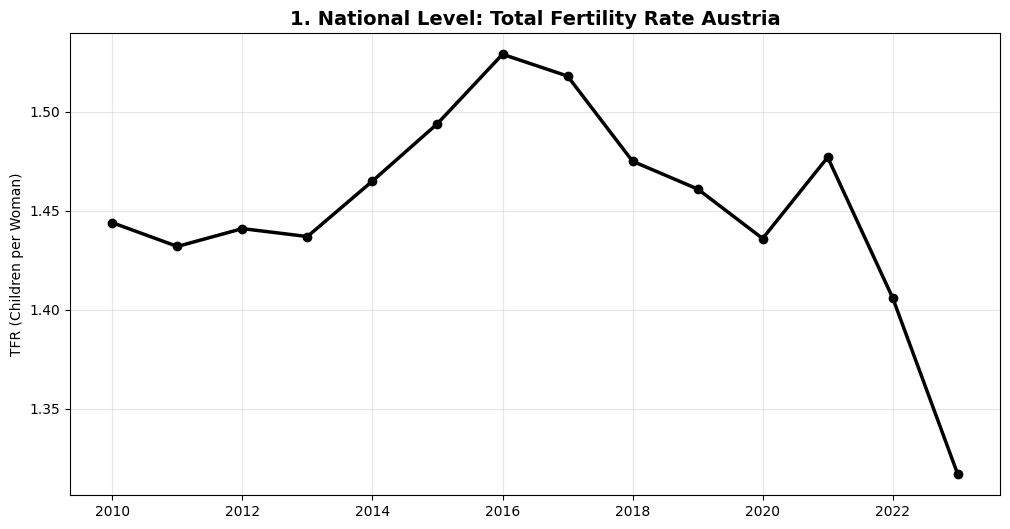

In [34]:
# --- PLOT 1: National (Austrian Average) ---
plt.figure(figsize=(12, 6))

plt.plot(at_master["year"], at_master["TFR"], color="black", linewidth=2.5, marker="o")
plt.title("1. National Level: Total Fertility Rate Austria", fontsize=14, fontweight="bold")
plt.ylabel("TFR (Children per Woman)")
plt.grid(True, alpha=0.3)

# IMPORTANT: Close the plot so the subsequent Markdown analysis displays correctly!
plt.show()

The time series of the Austrian average shows distinct dynamics:
- **2002 - 2010:** The rate fluctuated at a low level.
- **2010 - 2013:** A phase of stagnation.
- **2016:** The peak of the observed period was reached here. This could be related to strong immigration and economic stability.
- **2017 - 2020:** A continuous decline.
- **2021:** A brief "Corona bump" upwards – the lockdown period temporarily led to more births.
- **2022 - present:** A massive drop to a historical low (minimum). Rising living costs and global uncertainties are clearly reflected here.

### Analysis: Comparison of Major Regions (NUTS-1)

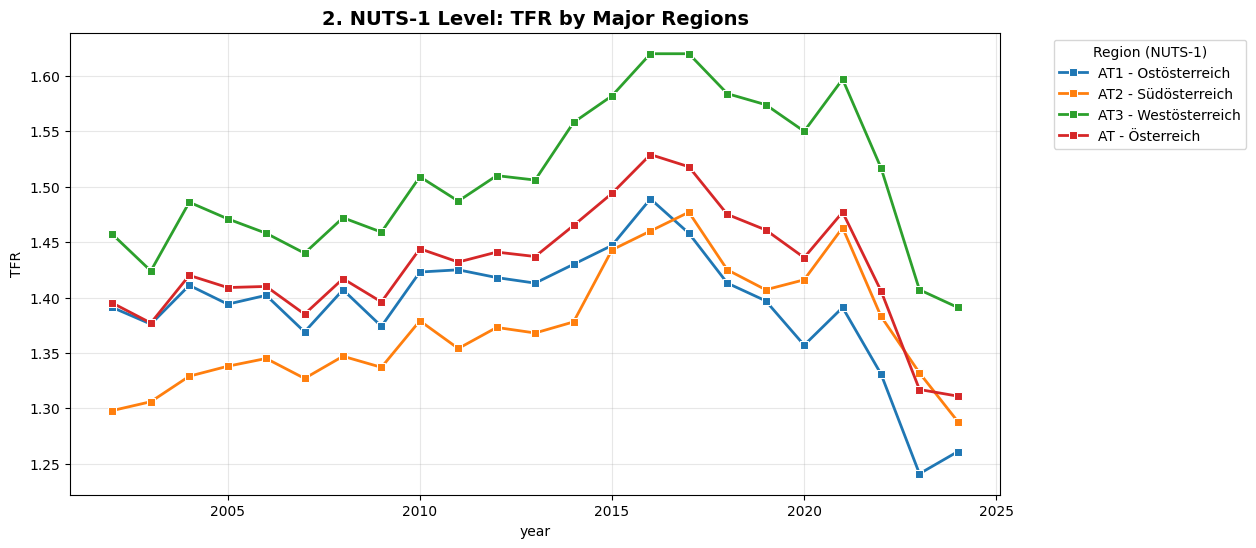

In [35]:
plt.figure(figsize=(12,6))
sns.lineplot(data=tfr_nuts1, x="year", y="TFR", hue="name", marker="s", linewidth=2)
plt.title("2. NUTS-1 Level: TFR by Major Regions", fontsize=14, fontweight="bold")
plt.ylabel("TFR")
plt.grid(True, alpha=0.3)
plt.legend(title="Region (NUTS-1)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The regional comparison shows a clear West-East divide:
- **Western Austria (Tyrol, Vorarlberg, Salzburg):** Traditionally consistently above the national average. Family structures appear to be the most stable here.
- **Eastern Austria (Vienna, Lower Austria, Burgenland):** Followed the upward trend until 2016, but then declined at an above-average rate, primarily driven by the Vienna metropolitan area.
- **Southern Austria (Carinthia, Styria):** This region tracks the national average curve almost perfectly, while consistently remaining slightly below the overall mean.

### Analysis: Detailed View of Federal States (NUTS-2)

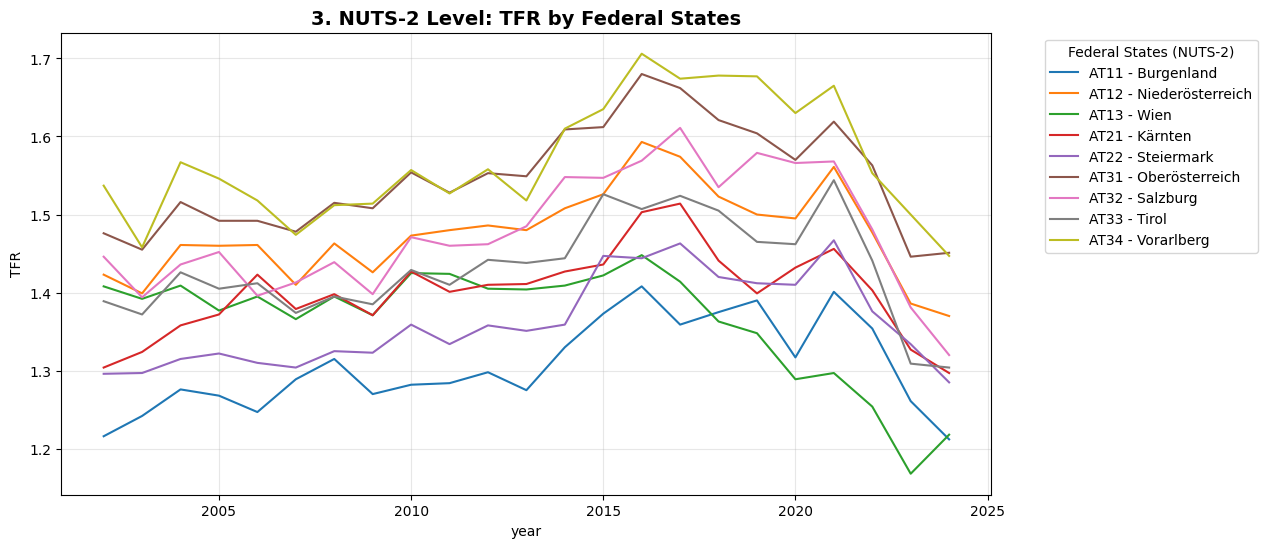

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(data=tfr_nuts2, x="year", y="TFR", hue="name", palette="tab10", linewidth=1.5)
plt.title("3. NUTS-2 Level: TFR by Federal States", fontsize=14, fontweight="bold")
plt.ylabel("TFR")
plt.grid(True, alpha=0.3)
# Move the legend outside the plot area to avoid covering the lines
plt.legend(title="Federal States (NUTS-2)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The granular analysis of the nine federal states confirms the western trend:
- **Top tier:** Vorarlberg and Upper Austria lead the ranking over almost the entire period.
- **Bottom tier:** Burgenland was often at the bottom until around 2018, but was then able to stabilize slightly.
- **Special case Vienna:** While Vienna was still in the middle of the pack around 2016, it has taken the last place in recent years and now records the lowest rates. This is typical for growing urbanization and high urban housing costs.
- **The "Standard":** Statistically speaking, Styria is the most "average" federal state and mirrors the national trend most accurately.

## Merging Birth Rate and GRP Data

To analyze the relationship between economic output and birth rate, the two datasets are merged using:

- NUTS-Code (region)
- year (time)

This creates a combined dataset with both variables for each region-year observation.

In [37]:
merged = birthrate.merge(
    grp,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged.head())
print(merged.shape)

  NUTS-Code  year  birth_rate            Region    GRP
0     AT111  2002       7.260  Mittelburgenland  599.0
1     AT111  2003       6.693  Mittelburgenland  636.0
2     AT111  2004       7.744  Mittelburgenland  645.0
3     AT111  2005       7.265  Mittelburgenland  666.0
4     AT111  2006       6.942  Mittelburgenland  703.0
(770, 5)


In [38]:
corr_br_grp = merged["birth_rate"].corr(merged["GRP"])
print(f"Correlation between Crude Birth Rate and Total GRP: {corr_br_grp:.3f}")

Correlation between Crude Birth Rate and Total GRP: 0.325


### Birth Rate vs GRP

A scatter plot is used to visualize the relationship between gross regional product (GRP) and birth rate.

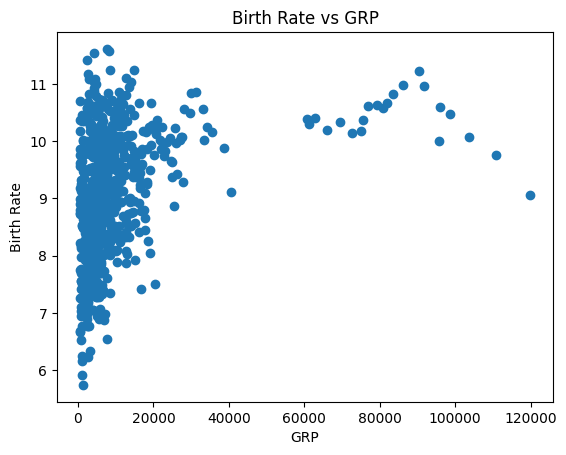

In [39]:
plt.figure()
plt.scatter(merged["GRP"], merged["birth_rate"])
plt.xlabel("GRP")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP")
plt.show()

## Observation

The scatter plot shows that the data points appear compressed along the horizontal axis. This is due to the large difference in scale between the variables:

- GRP values range from a few hundred to over 100,000
- Birth rates range only between approximately 5 and 12

This large variation in GRP is expected, as GRP represents the total economic output of a region. Larger regions with higher population and economic activity naturally have much higher GRP values than smaller regions.

However, this also highlights a conceptual issue: GRP is an absolute measure, while birth rate is a relative measure (per 1,000 people). As a result, comparing these two variables directly is not meaningful.

For a more appropriate analysis, GRP per capita will be used in the following step, as it provides a normalized measure of economic output that allows for better comparison across regions.

## Using GRP per Capita for Analysis

To obtain a more meaningful comparison, GRP per capita is used instead of total GRP. This normalizes economic output by population size and allows for better comparison between regions of different sizes.

In [40]:
merged_pc = birthrate.merge(
    grp_pc,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged_pc.head())
print(merged_pc.shape)

  NUTS-Code  year  birth_rate            Region  GRP_per_capita
0     AT111  2002       7.260  Mittelburgenland         15900.0
1     AT111  2003       6.693  Mittelburgenland         16900.0
2     AT111  2004       7.744  Mittelburgenland         17200.0
3     AT111  2005       7.265  Mittelburgenland         17800.0
4     AT111  2006       6.942  Mittelburgenland         18800.0
(770, 5)


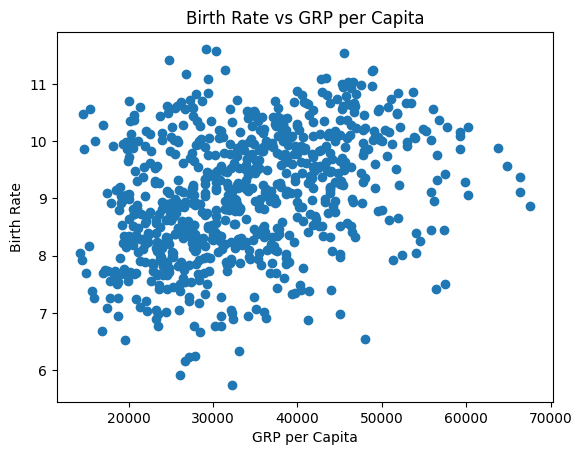

In [41]:
plt.figure()
plt.scatter(merged_pc["GRP_per_capita"], merged_pc["birth_rate"])
plt.xlabel("GRP per Capita")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP per Capita")
plt.show()

In [42]:
corr_br_grp_pc = merged_pc["birth_rate"].corr(merged_pc["GRP_per_capita"])
print(f"Correlation between Crude Birth Rate and GRP per Capita: {corr_br_grp_pc:.3f}")

Correlation between Crude Birth Rate and GRP per Capita: 0.358


## Observation

The correlation between birth rate and GRP per capita is positive but moderate (approximately 0.36).

This suggests that regions with higher economic output per person tend to have slightly higher birth rates. However, the relationship is not strong, indicating that economic conditions alone do not fully explain differences in birth rates.

While there appears to be a tendency for more economically developed regions to have somewhat higher birth rates in this dataset, other factors—such as social structure, urbanization, or policy—are likely to play an important role.

Overall, GRP per capita shows some association with birth rate, but it is not a strong predictor on its own.

## Regional Analysis: Economic Output vs. Fertility (NUTS-3 Panel Data)

To understand the relationship between economic conditions and demographic behavior on a local level, we analyze the dataset across all 35 Austrian NUTS-3 regions and all available years. 

We use **Gross Regional Product (GRP) per capita** to normalize the economic output by population size. Crucially, we use the **Total Fertility Rate (TFR)** rather than the crude birth rate. The crude birth rate can be heavily skewed by the age structure of a region (e.g., economic hubs attract young workers, leading to more births simply because there are more young people). The TFR adjusts for this demographic distortion, providing a much more accurate reflection of actual family planning behavior.

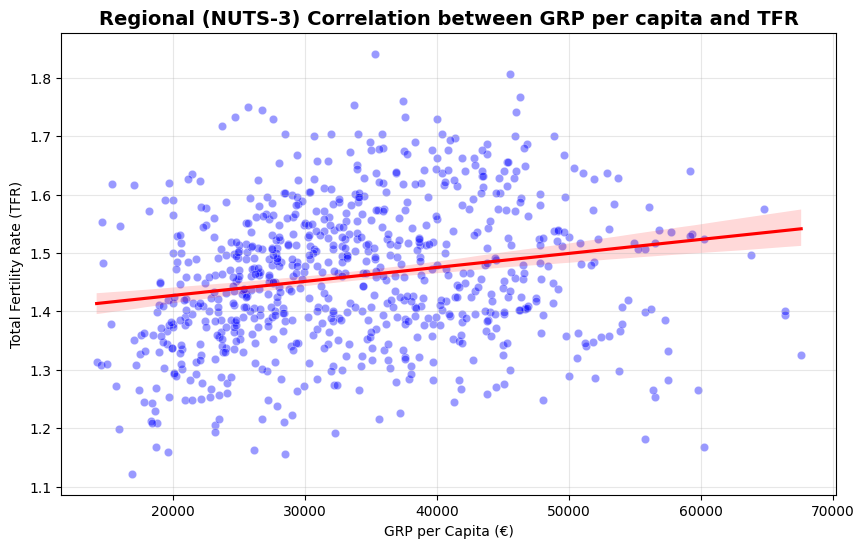

In [43]:
tfr_nuts3 = load_collection("clean_fertility_rate")

# Now we can safely convert and merge
tfr_nuts3["year"] = tfr_nuts3["year"].astype(int)
grp_pc_nuts3 = grp_pc.copy()
grp_pc_nuts3["year"] = grp_pc_nuts3["year"].astype(int)

merged_nuts3 = tfr_nuts3.merge(grp_pc_nuts3, on=["NUTS-Code", "year"], how="inner")

plt.figure(figsize=(10, 6))

# Scatterplot for all data points
sns.scatterplot(
    data=merged_nuts3, 
    x="GRP_per_capita", 
    y="TFR", 
    alpha=0.4, 
    color='blue'
)

# Overlay a regression line to visualize the (weak) trend
sns.regplot(
    data=merged_nuts3, 
    x="GRP_per_capita", 
    y="TFR", 
    scatter=False, 
    color='red'
)

plt.title("Regional (NUTS-3) Correlation between GRP per capita and TFR", fontsize=14, fontweight="bold")
plt.xlabel("GRP per Capita (€)")
plt.ylabel("Total Fertility Rate (TFR)")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
corr_tfr_grp_pc = merged_nuts3["TFR"].corr(merged_nuts3["GRP_per_capita"])
print(f"Correlation between TFR and GRP per Capita: {corr_tfr_grp_pc:.3f}")

Correlation between TFR and GRP per Capita: 0.202


## Observation: Regional Economic Output and Fertility

The correlation between TFR and GRP per capita across all regional data points is weakly positive (r = 0.202). 

Interestingly, this is significantly lower than correlations often observed when using the unadjusted crude birth rate (which previously showed r = 0.358). This discrepancy perfectly illustrates why TFR is the superior metric: while wealthy urban centers might have a high *number* of births due to a young workforce, the actual *propensity* of individual women to have children in these areas is much less pronounced once adjusted for age.

Ultimately, the weak positive correlation (0.202) suggests that while higher regional economic output might provide slightly better infrastructural or financial environments for families, it is not a strong or decisive driver of fertility on its own.

## Macroeconomic Trends vs. Fertility Rate Over Time (National Level)

Having examined the spatial (regional) differences, we now shift our focus to the temporal dimension. We leverage our consolidated National Master Dataset (`austria_master_summary`) to observe how general macroeconomic growth impacts demographic behavior over time. 

We compare the national **GRP per capita** with the national **Total Fertility Rate (TFR)** to see if the accumulation of wealth in the Austrian economy over the past two decades corresponds with changing fertility trends.

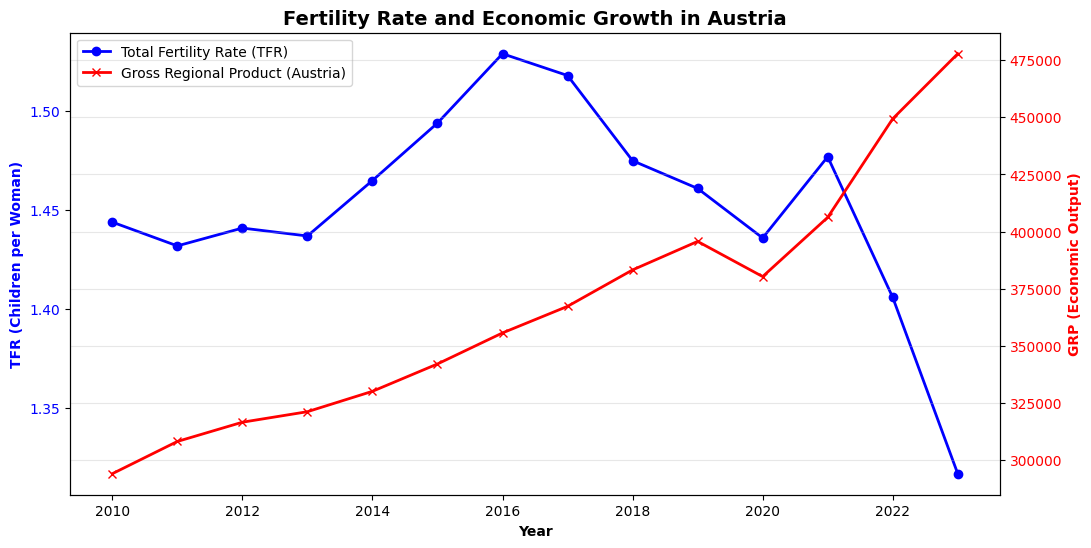

In [45]:
# Use the prepared master table directly! No groupby() needed anymore.
fig, ax1 = plt.subplots(figsize=(12, 6)) # Adjust figsize for a wider, cleaner plot

# Total Fertility Rate (TFR) on the left y-axis
line1 = ax1.plot(
    at_master["year"],
    at_master["TFR"], 
    label="Total Fertility Rate (TFR)",
    color="blue",
    marker="o", # Add small markers for better readability
    linewidth=2
)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

# GRP on the right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    at_master["year"],
    at_master["GRP"], 
    label="Gross Regional Product (Austria)",
    color="red",
    marker="x",
    linewidth=2
)
ax2.set_ylabel("GRP (Economic Output)", color="red", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="red")

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Fertility Rate and Economic Growth in Austria", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3) # Add a light grid for better readability
plt.show()

In [46]:
corr_tfr_grp = at_master["TFR"].corr(at_master["GRP"])
print(f"Correlation (TFR vs GRP): {corr_tfr_grp:.3f}")

Correlation (TFR vs GRP): -0.463


## Observation: Economic Growth vs. Fertility Over Time

The correlation between the national GRP per capita and the national TFR over time is moderately negative (r = -0.463).

This presents a fascinating statistical contrast to our regional analysis. While living in a wealthier *region* at a given point in time shows a weak positive association with fertility (r = 0.202), the long-term *national* trend behaves in the exact opposite manner.

As the overall Austrian economy has grown and generated more wealth per capita over the last two decades, fertility rates have generally declined. This aligns with well-documented demographic modernization theories: as societies become wealthier over time, structural changes—such as longer education periods, higher female labor force participation, and increased opportunity costs—often lead to lower birth rates.

## Housing Prices and Fertility Rate

In addition to general economic output, the specific cost of living—particularly housing prices—may heavily influence demographic behavior. High housing costs can delay or negatively affect decisions related to family formation.

Since we have already consolidated our data in the National Master Dataset, we can directly compare the **Housing Price Index (HPI)** with the **Total Fertility Rate (TFR)** over time. We calculate the correlation to see if rising housing costs are statistically associated with a decline in fertility across Austria.

In [47]:
hpi = load_collection("clean_HPI")

print(hpi.head())

   Jahr           HPI_type     HPI
0  2010  Bestehende Häuser  100.00
1  2011  Bestehende Häuser  103.65
2  2012  Bestehende Häuser  108.55
3  2013  Bestehende Häuser  112.25
4  2014  Bestehende Häuser  114.09


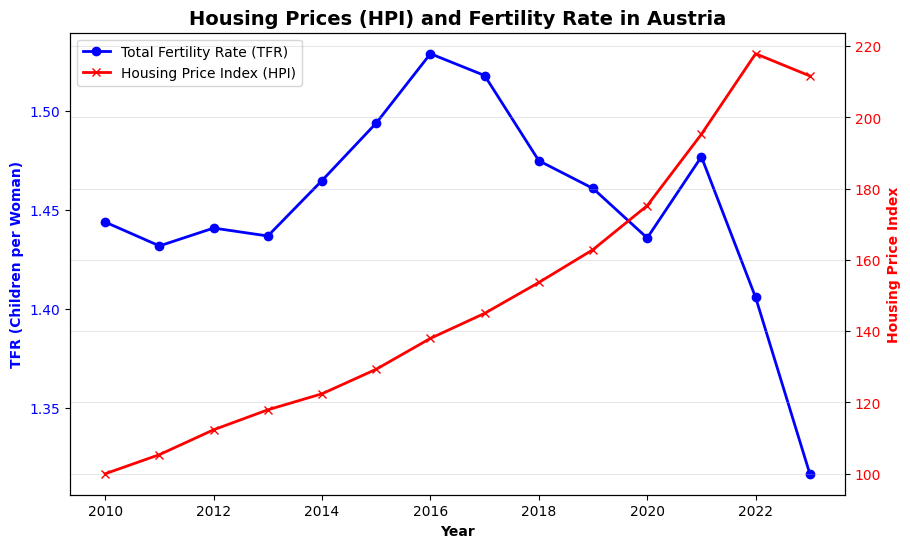

In [48]:
# The entire preparation is skipped, we use our master table 'at_master' directly!

fig, ax1 = plt.subplots(figsize=(10, 6))

# TFR on the left y-axis
line1 = ax1.plot(
    at_master["year"], 
    at_master["TFR"], 
    label="Total Fertility Rate (TFR)", 
    color="blue", 
    marker="o",
    linewidth=2
)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

# HPI on the right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    at_master["year"], 
    at_master["HPI"], 
    label="Housing Price Index (HPI)", 
    color="red", 
    marker="x",
    linewidth=2
)
ax2.set_ylabel("Housing Price Index", color="red", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="red")

# Combine legends (so both lines are in a single box)
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Housing Prices (HPI) and Fertility Rate in Austria", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
corr_tfr_hpi = at_master["TFR"].corr(at_master["HPI"])
print(f"Correlation (TFR vs HPI): {corr_tfr_hpi:.3f}")

Correlation (TFR vs HPI): -0.414


## Observation: Housing Prices vs. Fertility Rate

The time series shows that housing prices have increased steadily over the observed period, while fertility rates have generally declined, especially in recent years.

The correlation between the Total Fertility Rate (TFR) and the Housing Price Index (HPI) is moderately negative (r = -0.414). This confirms the hypothesis that higher housing costs are indeed associated with lower fertility rates.

Interestingly, this negative correlation is very similar in strength to the general economic growth trend (national GRP per capita over time, r = -0.463). This indicates that rising housing prices are closely tied to the broader macroeconomic dynamic: as the economy grows, the cost of living increases disproportionately in the housing sector, which acts as a structural headwind to family planning. 

However, since the correlation is moderate (-0.414), housing prices are not the sole determining factor. Variations in fertility are ultimately driven by a complex mix of economic pressures, labor market dynamics, and cultural shifts.

## Labor Market Dynamics: Employment Rate vs. Fertility

Beyond housing costs and general economic output, the labor market plays a crucial role in family planning. A secure job provides the financial foundation for starting a family, yet high employment rates—especially among women—can also increase the opportunity costs of having children.

Using our National Master Dataset, we compare the **Total Employment Rate (Quote_Zusammen)** with the **Total Fertility Rate (TFR)** over time to evaluate how labor market participation correlates with demographic trends in Austria.

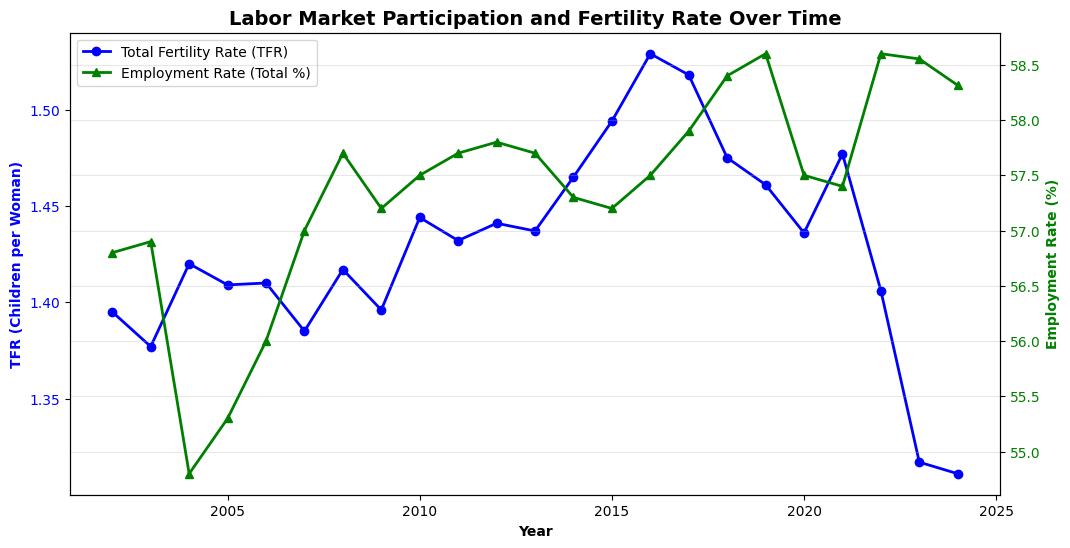

In [50]:
# Merge at_tfr and emp_clean (matching 'year' with 'Jahr')
merged_emp_tfr = at_tfr.merge(emp_clean, left_on="year", right_on="Jahr", how="inner")

fig, ax1 = plt.subplots(figsize=(12, 6))

# TFR on the left y-axis
line1 = ax1.plot(
    merged_emp_tfr["year"], 
    merged_emp_tfr["TFR"], 
    label="Total Fertility Rate (TFR)", 
    color="blue", 
    marker="o",
    linewidth=2
)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

# Total Employment Rate (Quote_Zusammen) on the right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    merged_emp_tfr["year"], 
    merged_emp_tfr["Quote_Zusammen"], 
    label="Employment Rate (Total %)", 
    color="green", 
    marker="^", 
    linewidth=2
)
ax2.set_ylabel("Employment Rate (%)", color="green", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="green")

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Labor Market Participation and Fertility Rate Over Time", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
corr_emp_total = merged_emp_tfr["TFR"].corr(merged_emp_tfr["Quote_Zusammen"])
print(f"Correlation (TFR vs. Total Employment Rate): {corr_emp_total:.3f}")

Correlation (TFR vs. Total Employment Rate): 0.023


## Observation: Total Employment Rate vs. Fertility

At first glance, plotting the Total Employment Rate against the Total Fertility Rate (TFR) reveals a highly volatile relationship over the last two decades. 

The calculated correlation is near zero (r = 0.023), indicating no linear relationship between the overall labor market participation and birth rates. A visual inspection of the chart explains why:
- During certain economic upswings (e.g., 2005–2008), employment and fertility rose simultaneously.
- Conversely, in recent years (2016–2019), record-high employment rates coincided with a sharp decline in fertility. 
- In the post-pandemic phase (2022 onwards), employment recovered strongly while the TFR crashed to historical lows.

**Conclusion:** The overall employment rate is not a stable predictor for demographic behavior. The decision to have children is likely influenced by much more specific factors than general labor market participation, such as job security, inflation, housing costs (as seen in our HPI analysis), or gender-specific career dynamics.

## Gender-Specific Labor Dynamics: Female Employment vs. Fertility

Since the overall employment rate showed no correlation with fertility (r = 0.023), we must look deeper. The intersection of career and family planning historically and structurally impacts women more than men. 

Therefore, we isolate the **Female Employment Rate (`Quote_Frauen`)** to test a well-established demographic theory: Does increased female participation in the workforce—and the associated rise in opportunity costs—correlate with a decline in the Total Fertility Rate?

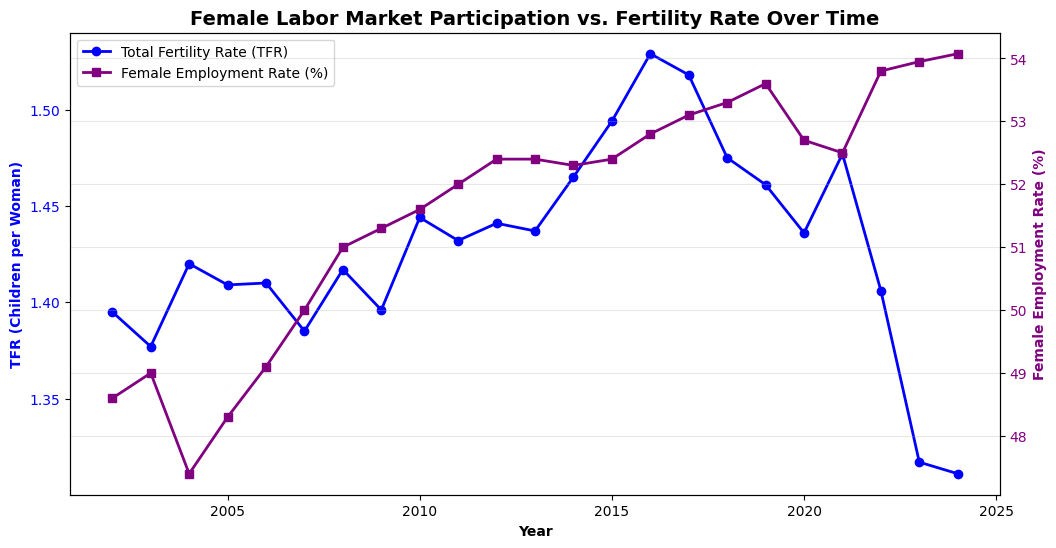

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# TFR on the left y-axis (remains blue)
line1 = ax1.plot(
    merged_emp_tfr["year"], 
    merged_emp_tfr["TFR"], 
    label="Total Fertility Rate (TFR)", 
    color="blue", 
    marker="o",
    linewidth=2
)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

# Female Employment Rate on the right y-axis (using purple for distinction)
ax2 = ax1.twinx()
line2 = ax2.plot(
    merged_emp_tfr["year"], 
    merged_emp_tfr["Quote_Frauen"], 
    label="Female Employment Rate (%)", 
    color="purple", 
    marker="s", # 's' for Square marker
    linewidth=2
)
ax2.set_ylabel("Female Employment Rate (%)", color="purple", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="purple")

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Female Labor Market Participation vs. Fertility Rate Over Time", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
corr_emp_female = merged_emp_tfr["TFR"].corr(merged_emp_tfr["Quote_Frauen"])
print(f"Correlation (TFR vs. Female Employment Rate): {corr_emp_female:.3f}")

Correlation (TFR vs. Female Employment Rate): 0.176


## Observation:

Analyzing the entire available timeline (2002 to present), the correlation between the Female Employment Rate and the Total Fertility Rate is weakly positive (r = 0.176). 

This weak overall correlation suggests that taking the entire two-decade span as a single block obscures the underlying dynamics. Over a 20-year period, a country experiences multiple "structural breaks"—major shifts in family policy, economic crises, and cultural changes—that can cause variables to interact differently at different times.

### Methodological Note: Isolating a Stable Economic Period

To uncover true sociological trends, it is standard practice to filter out extreme outlier years (such as early 2000s policy shifts or the unprecedented post-2021 inflation/energy crisis). By narrowing our focus to the relatively stable macroeconomic core period of **2007 to 2021**, we can observe how female labor market participation and family planning interact without the noise of extreme external shocks.

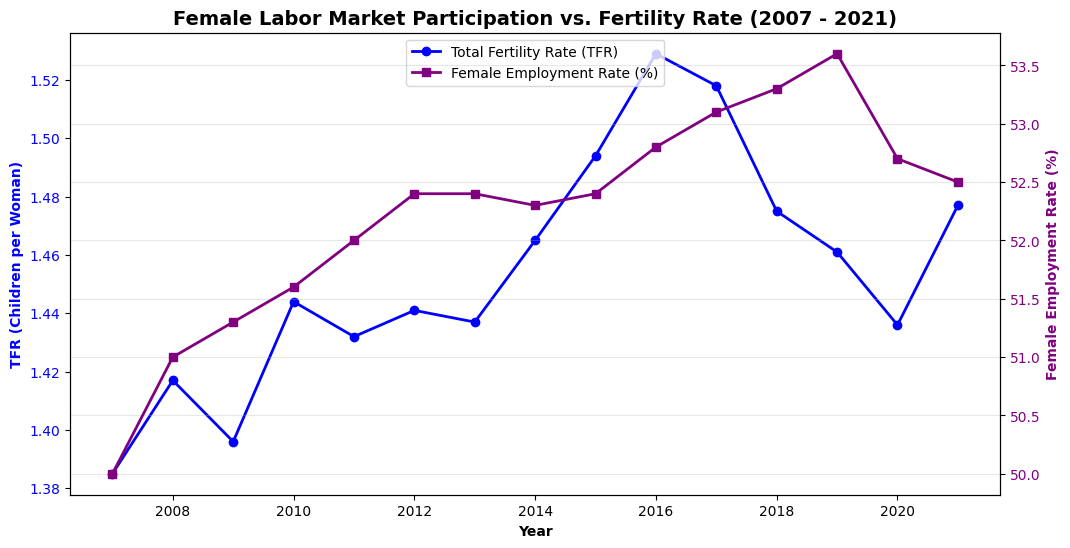

In [54]:
# 1. Filter data (only years from 2007 to 2021)
filtered_emp_tfr = merged_emp_tfr[(merged_emp_tfr["year"] >= 2007) & (merged_emp_tfr["year"] <= 2021)].copy()

# 2. Create plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# TFR on the left y-axis
line1 = ax1.plot(
    filtered_emp_tfr["year"], 
    filtered_emp_tfr["TFR"], 
    label="Total Fertility Rate (TFR)", 
    color="blue", 
    marker="o",
    linewidth=2
)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

# Female Employment Rate on the right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    filtered_emp_tfr["year"], 
    filtered_emp_tfr["Quote_Frauen"], 
    label="Female Employment Rate (%)", 
    color="purple", 
    marker="s", 
    linewidth=2
)
ax2.set_ylabel("Female Employment Rate (%)", color="purple", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="purple")

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper center")

plt.title("Female Labor Market Participation vs. Fertility Rate (2007 - 2021)", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# Calculate Correlation for the filtered timeframe
corr_emp_female_filtered = filtered_emp_tfr["TFR"].corr(filtered_emp_tfr["Quote_Frauen"])
print(f"Correlation (TFR vs. Female Employment, 2007-2021): {corr_emp_female_filtered:.3f}")

Correlation (TFR vs. Female Employment, 2007-2021): 0.739


## Observation: The Compatibility of Career and Family (2007 - 2021)

Isolating the core period from 2007 to 2021 reveals a striking shift in the data. While the overall timeframe showed little to no correlation (r = 0.176), focusing on this 15-year window exposes a **strong positive correlation (r = 0.739)** between the female employment rate and the Total Fertility Rate (TFR).

This finding powerfully challenges the traditional economic assumption that higher female workforce participation automatically leads to lower birth rates due to opportunity costs. Instead, it highlights a modern demographic phenomenon: when institutional frameworks improve—such as the expansion of childcare facilities, flexible working hours, and modernized parental leave policies (which were heavily promoted in Austria during this era)—women are less forced to choose between a career and a family. 

During this stable macroeconomic period, rising female employment and rising fertility went hand in hand. However, the fact that this correlation breaks down when including the post-2021 data suggests that recent severe economic shocks (like inflation and housing crises) may have disrupted this delicate work-life balance.

## Economic Uncertainty: Unemployment Rate vs. Fertility

While the employment rate reflects labor market participation, the **Unemployment Rate** serves as a direct indicator of economic insecurity and societal stress. Economic uncertainty is fundamentally linked to demographic behavior: when individuals face the risk of job loss or a lack of career prospects, establishing a family or having additional children is often postponed.

In this section, we analyze the relationship between unemployment and the Total Fertility Rate (TFR). We examine both the **Total Unemployment Rate** and the **Female Unemployment Rate**, as the perceived economic risk might influence family planning differently depending on gender dynamics.

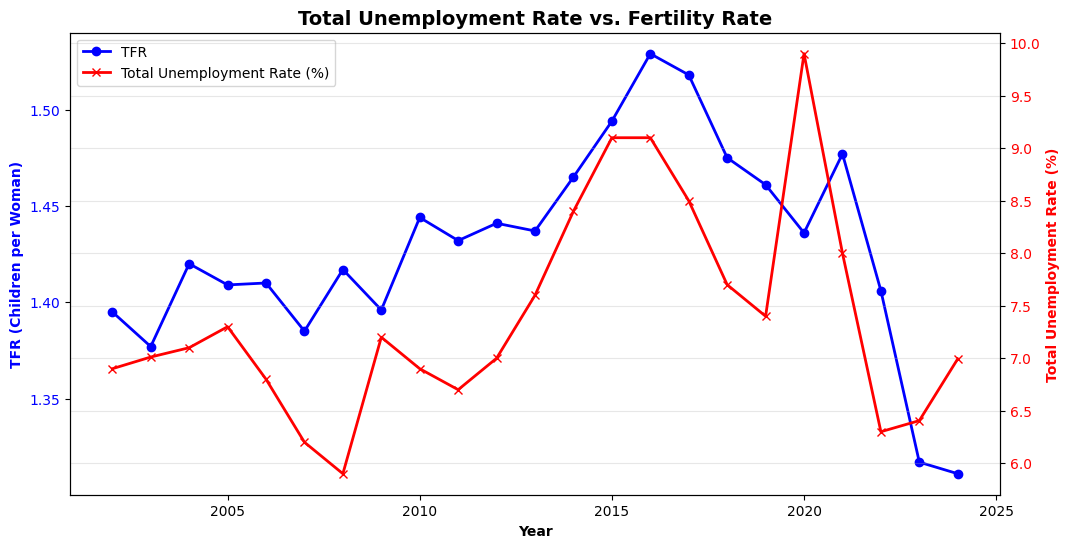

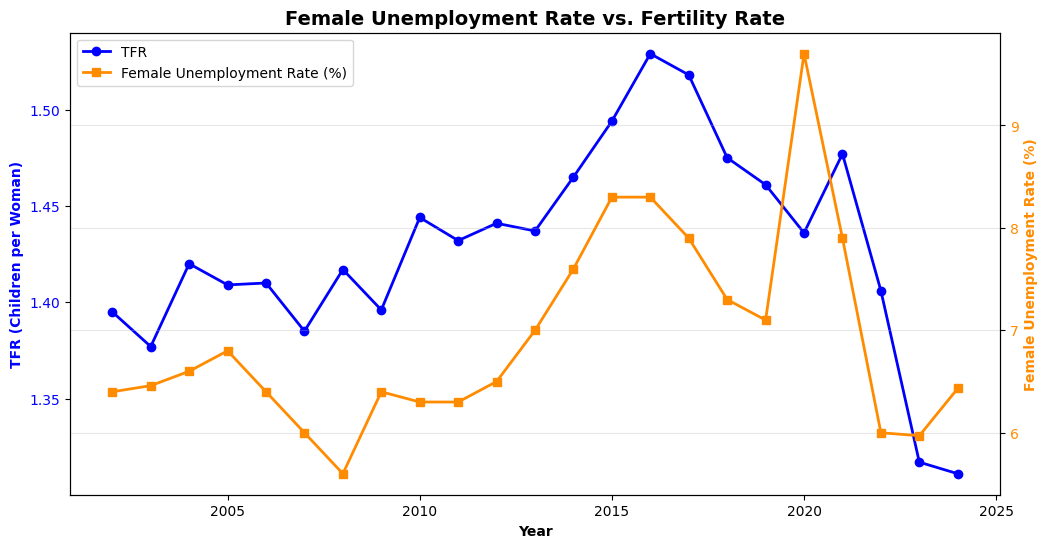

In [56]:
# 1. Merge data (at_tfr and unemp_clean)
merged_unemp_tfr = at_tfr.merge(unemp_clean, left_on="year", right_on="Jahr", how="inner")

# 2. Plot 1: Total Unemployment
fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = ax1.plot(merged_unemp_tfr["year"], merged_unemp_tfr["TFR"], label="TFR", color="blue", marker="o", linewidth=2)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
line2 = ax2.plot(merged_unemp_tfr["year"], merged_unemp_tfr["Arbeitslosenquote_Zusammen"], label="Total Unemployment Rate (%)", color="red", marker="x", linewidth=2)
ax2.set_ylabel("Total Unemployment Rate (%)", color="red", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="red")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")
plt.title("Total Unemployment Rate vs. Fertility Rate", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plot 2: Female Unemployment
fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = ax1.plot(merged_unemp_tfr["year"], merged_unemp_tfr["TFR"], label="TFR", color="blue", marker="o", linewidth=2)
ax1.set_xlabel("Year", fontweight="bold")
ax1.set_ylabel("TFR (Children per Woman)", color="blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
line2 = ax2.plot(merged_unemp_tfr["year"], merged_unemp_tfr["Arbeitslosenquote_Frauen"], label="Female Unemployment Rate (%)", color="darkorange", marker="s", linewidth=2)
ax2.set_ylabel("Female Unemployment Rate (%)", color="darkorange", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")
plt.title("Female Unemployment Rate vs. Fertility Rate", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Calculate Correlations
corr_unemp_total = merged_unemp_tfr["TFR"].corr(merged_unemp_tfr["Arbeitslosenquote_Zusammen"])
corr_unemp_female = merged_unemp_tfr["TFR"].corr(merged_unemp_tfr["Arbeitslosenquote_Frauen"])

print(f"Correlation (TFR vs. Total Unemployment): {corr_unemp_total:.3f}")
print(f"Correlation (TFR vs. Female Unemployment): {corr_unemp_female:.3f}")

Correlation (TFR vs. Total Unemployment): 0.645
Correlation (TFR vs. Female Unemployment): 0.631


## Observation: The "Time Lag" and Opportunity Costs

At first glance, the strong positive correlation between unemployment and fertility (r = 0.645 for total, r = 0.631 for female) seems highly counterintuitive. One would expect economic insecurity to lower birth rates. However, a closer visual inspection of the timeline reveals two critical demographic concepts:

1. **The Time Lag Effect:** Until 2019, the two curves appear to follow a similar trajectory but with a 1-to-2-year delay. This is biologically and sociologically logical: economic conditions in a given year influence family planning decisions that only manifest in birth rates a year or two later.
2. **Opportunity Cost Theory:** During phases of high unemployment, the career-related opportunity costs of having a child decrease. For some demographics, a difficult labor market makes taking time off for family planning a more viable or less economically penalizing option.

## Timeline Breakdown: Shocks and The Great Divergence

Breaking down the timeline reveals how external shocks dictate this relationship:
- **The 2015/2016 Peak:** Both unemployment and fertility spiked simultaneously. This was heavily influenced by the European migration crisis. A large influx of new residents temporarily drove up both the unemployment rate (as new arrivals entered the labor market) and the TFR.
- **The 2020 Anomaly:** The Covid-19 pandemic is the only year that perfectly matches intuitive expectations. Lockdowns caused a massive, immediate spike in unemployment, while the TFR dropped. 
- **The Post-2021 Divergence:** In the 2020s, the historical pattern breaks completely. Unemployment has dropped significantly due to labor shortages, but the TFR has plummeted to historical lows. This indicates a "regime change" in the data: job security is currently high, but it is being entirely overridden by the massive inflation and cost-of-living crisis, which now dominates family planning decisions.

### Methodological Note: An Apparent Paradox Explained

A bivariate view presents a seemingly contradictory finding: How can both the Female Employment Rate (r = 0.739 between 2007-2021) and the Total Unemployment Rate (r = 0.645 overall) correlate positively with the TFR? 

This highlights the complexity of demographic statistics:
1. **Different Drivers:** The employment correlation is driven by a slow, structural long-term trend (better childcare enabling working mothers during a specific 15-year window). The unemployment correlation is heavily driven by a massive overlapping shock event (the 2015/2016 peak where both metrics spiked simultaneously).
2. **Labor Force Math:** Employment and unemployment rates are not strict mathematical inverses. As more women moved from "inactive" (homemakers) to "active" participants in the labor force over the last two decades, employment rates rose structurally, largely independent of cyclical unemployment spikes.

This paradox perfectly demonstrates why our **Multivariate Forward Selection** (in the section below) is essential. It prevents us from drawing flawed conclusions from single-variable correlations by isolating the true, non-redundant macroeconomic drivers.

---

## Multivariate Analysis: Forward Selection Model

So far, we have analyzed macroeconomic and labor market indicators in isolation (bivariate analysis). However, in reality, variables like GDP per capita, housing prices, employment, and unemployment are highly interlinked. 

To determine which of these variables truly drive the Total Fertility Rate (TFR) without double-counting overlapping effects, we apply a **Forward Selection** approach using Multiple Linear Regression. 

The algorithm starts with an empty model and iteratively adds the variable that improves the model's explanatory power the most. We evaluate the models using the **Adjusted R-squared**, which represents the percentage of variance in the TFR explained by the combination of variables, while mathematically penalizing the addition of variables that do not add meaningful information.

In [60]:
import statsmodels.api as sm

# 1. Use the finalized master table
model_data = at_master.copy()

# 2. Define the target and macro features
target = 'TFR'

# Select main indicators to avoid redundant overlaps
features = [
    'GRP', 
    'HPI', 
    'Quote_Zusammen', 
    'Arbeitslosenquote_Zusammen'
]

# 3. Forward Selection Algorithm
def forward_selection(data, target_col, candidate_features):
    remaining_features = list(candidate_features)
    selected_features = []
    current_score, best_new_score = 0.0, 0.0
    
    print("--- Forward Selection Process ---")
    
    while remaining_features and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining_features:
            # Model with previously selected features + new candidate
            X_cols = selected_features + [candidate]
            X = sm.add_constant(data[X_cols])
            y = data[target_col]
            
            # OLS Regression
            model = sm.OLS(y, X).fit()
            r2_adj = model.rsquared_adj
            scores_with_candidates.append((r2_adj, candidate))
            
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        
        # Add variable if the new score is significantly better than the old one
        if best_new_score > current_score:
            remaining_features.remove(best_candidate)
            selected_features.append(best_candidate)
            current_score = best_new_score
            print(f"Added: {best_candidate.ljust(30)} | Adjusted R-squared: {current_score:.4f}")
        else:
            print(f"Stopped. Adding further variables does not improve the model.")
            break
            
    return selected_features

# 4. Execute the model
final_features = forward_selection(model_data, target, features)
print("\nFinal selected features that drive TFR:", final_features)

--- Forward Selection Process ---
Added: Arbeitslosenquote_Zusammen     | Adjusted R-squared: 0.3574
Added: GRP                            | Adjusted R-squared: 0.4431
Stopped. Adding further variables does not improve the model.

Final selected features that drive TFR: ['Arbeitslosenquote_Zusammen', 'GRP']


In [ ]:
import numpy as np
import statsmodels.api as sm

# 1. Winning variables from Forward Selection
final_features = ['Arbeitslosenquote_Zusammen', 'GRP']

# 2. Prepare data for the final model
X_final = sm.add_constant(at_master[final_features])
y_final = at_master['TFR']

# 3. Fit the final model
final_model = sm.OLS(y_final, X_final).fit()

# 4. Extract values and calculate Multiple R
r_squared = final_model.rsquared
r_squared_adj = final_model.rsquared_adj
multiple_r = np.sqrt(r_squared)

print("--- Final Model Performance ---")
print(f"R-squared:          {r_squared:.4f}")
print(f"Adjusted R-squared: {r_squared_adj:.4f}")
print(f"Multiple R (Correlation): {multiple_r:.3f}")

--- Final Model Performance ---
R-squared:          0.5288
Adjusted R-squared: 0.4431
Multiple R (Correlation): 0.727


## Observation: Multivariate Drivers of Fertility

The Forward Selection model provides a fascinating, refined view of the macroeconomic forces that actually drive the Total Fertility Rate (TFR) in Austria.

The algorithm selected two distinct features to build the optimal model:
1. **Total Unemployment Rate** (capturing individual economic security and immediate labor market stress).
2. **Gross Regional Product / GRP** (capturing overarching macroeconomic wealth and national economic growth).

**Model Performance & Multiple Correlation:**
To make the statistical impact more tangible, we calculated the Multiple Correlation Coefficient (R) for this combined model. While individual factors like unemployment showed a correlation of r = 0.645, combining Unemployment and GRP yields a Multiple R of 0.727. 

This is a remarkably strong correlation. The model's Adjusted R-squared of 0.4431 means that over 44% of the variance in the Austrian birth rate can be explicitly explained by just these two economic indicators working together.

**The "Invisible" Variables (Multicollinearity):**
It is equally important to analyze what the model *rejected*. The algorithm chose to exclude Housing Prices (HPI) and the Total Employment Rate. 

This does not mean housing prices don't affect family planning. Rather, it demonstrates the statistical principle of **multicollinearity**: Housing prices rise almost in tandem with the general GRP. Once the model factored in the overall economic growth, the HPI offered no *additional* statistical value. Similarly, general employment is largely an inverse reflection of unemployment. 

When analyzing demographic behavior through a macroeconomic lens, one does not need every available metric. A combination of overarching economic output (GRP) and immediate personal job security (Unemployment Rate) serves as a highly robust, non-redundant proxy for the financial environment in which families make their decisions.

---
---


# Key findings

The analysis finds that Austria’s fertility decline is most strongly associated with economic pressure, especially housing costs and broader macroeconomic conditions. 

* **Clear regional gap:** Western Austria has the highest average fertility, while eastern and southern regions are lower. The west–east divide is consistent across the data.
* **Regional wealth matters only a little:** At regional level, richer areas show only a **weak positive relationship** with fertility. Economic output alone is not enough to explain differences.
* **National trend goes the other way:** Over time, as Austria’s overall economy grew, fertility still declined. This suggests that long-term modernization and rising living costs offset the benefits of growth.
* **Housing is a major factor:** Rising housing prices show a **moderate negative correlation** with fertility. This supports the idea that affordability pressures discourage family formation.
* **Overall employment is not useful as a predictor:** Total employment has almost no linear relationship with fertility.
* **Female employment is more nuanced:** Across the full period the relationship is weak, but from **2007–2021** it becomes **strongly positive**, suggesting fertility can coexist with higher female employment when childcare, flexibility, and policy support are stronger.
* **Unemployment shows a positive correlation, but this is misleading on its own:** The notebook interprets this as a mix of time-lag effects, shock years, and changing opportunity costs rather than a simple causal effect.
* **Best multivariate result:** The strongest combined model uses unemployment rate + GRP, with a multiple correlation of 0.727 and adjusted R² of 0.443. In other words, these two variables together explain about 44% of fertility variation in the model.

# Conclusion
The analysis suggests that Austria’s fertility decline is driven less by simple income levels and more by affordability and insecurity, especially housing costs and wider economic pressure. Regional prosperity alone does not explain fertility patterns, while rising living costs appear to weigh more heavily on family decisions. At the same time, the stronger recent link between female employment and fertility indicates that work and childbearing can be compatible when supported by the right institutions. Overall, the findings point to a clear implication: if Austria wants to stabilize fertility, policies should focus less on growth in general and more on lowering the practical cost and risk of having children.